In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
import json
from datetime import datetime
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

class Config:
    def __init__(self):
        # Paths
        self.FACTOR_DATA_PATH = 'Factordata'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_DATA_PATH, 'analysis_output__')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        
        # Analysis parameters
        self.RANDOM_STATE = 42
        self.N_ESTIMATORS = 200
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        
        # LSTM parameters
        self.SEQUENCE_LENGTH = 5
        self.LSTM_UNITS = 64
        self.DROPOUT_RATE = 0.2
        self.EPOCHS = 50
        self.BATCH_SIZE = 32
        self.VALIDATION_SPLIT = 0.2
        self.ENSEMBLE_THRESHOLD = 0.5

def load_economic_data(logger, min_date=None, max_date=None):
    """
    Load economic data from CSV files in root directory with fixed sentiment data parsing
    """
    try:
        data_loaders = {
            'gdp': {
                'file': 'gdp_data.csv',
                'date_col': 'year_quarter',
                'value_cols': ['real_q', 'tsd_cleaned'],
                'rename': {'real_q': 'gdp'}
            },
            'unemployment': {
                'file': 'combined_unemployment_data.csv',
                'sep': ';',
                'date_col': 'Date',
                'value_cols': ['UnemploymentRate'],
                'numeric_cleaning': True
            },
            'ks': {
                'file': 'ks_q_hist.csv',
                'date_col': 'date',
                'value_cols': ['value']
            },
            'inflation': {
                'file': 'inflation.csv',
                'date_col': 'Date',
                'value_cols': ['chinf', 'usinf', 'deinf'],
                'numeric_cleaning': True
            },
            'gold': {
                'file': 'gold.csv',
                'date_col': 'Date',
                'value_cols': ['GoldCHF']
            },
            'eur_chf': {
                'file': 'EUR_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'EUR_CHF_rate'}
            },
            'usd_eur': {
                'file': 'USD_EUR_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_EUR_rate'}
            },
            'usd_chf': {
                'file': 'USD_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_CHF_rate'}
            },
            'sentiment': {
                'file': 'Sentiment_Per_Month.csv',
                'date_col': 'Time',
                'value_cols': ['Sentiment_12M', 'Sentiment_24M'],
                'date_parser': lambda x: pd.to_datetime(x, format='mixed')
            }
        }

        datasets = {}
        for key, config in data_loaders.items():
            try:
                file_path = config['file']
                if not os.path.exists(file_path):
                    logger.warning(f"File not found: {file_path}")
                    continue

                df = pd.read_csv(file_path, sep=config.get('sep', ','))
                
                # Date parsing with custom parser if specified
                if config.get('date_parser'):
                    df['date'] = config['date_parser'](df[config['date_col']])
                else:
                    df['date'] = pd.to_datetime(df[config['date_col']])
                
                if config.get('numeric_cleaning'):
                    for col in config['value_cols']:
                        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
                
                if config.get('rename'):
                    df = df.rename(columns=config['rename'])
                
                df = df[['date'] + list(config.get('rename', {}).values() or config['value_cols'])]
                
                if min_date is not None and max_date is not None:
                    df = df[(df['date'] >= min_date) & (df['date'] <= max_date)]
                
                df = df.sort_values('date')
                datasets[key] = df

            except Exception as e:
                logger.warning(f"Error loading {key} data: {e}")
                continue

        # Merge all datasets
        if 'gdp' not in datasets:
            raise ValueError("GDP data is required but could not be loaded")
        
        data = datasets['gdp'].copy()
        
        # Modified: Use outer merge and then forward fill missing values
        for key in ['unemployment', 'ks', 'inflation', 'gold', 
                   'eur_chf', 'usd_eur', 'usd_chf', 'sentiment']:
            if key in datasets:
                data = pd.merge_asof(data.sort_values('date'), 
                                   datasets[key].sort_values('date'),
                                   on='date',
                                   direction='nearest',
                                   tolerance=pd.Timedelta('30D'))
                
        # Forward fill missing values and then backward fill any remaining
        data = data.fillna(method='ffill').fillna(method='bfill')
        data.set_index('date', inplace=True)
        logger.info(f"Economic data loaded and filtered successfully with shape: {data.shape}")
        return data

    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

class FactorAnomalyAnalyzer:
    def __init__(self, config):
        self.config = config
        self.logger = self._setup_logger()
        self.lstm_models = {}

    def _setup_logger(self):
        logger = logging.getLogger('factor_anomaly_analysis')
        logger.setLevel(logging.INFO)
        
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        
        # File handler
        log_file = os.path.join(self.config.OUTPUT_DIR, 
                               f'factor_analysis_log_{datetime.now():%Y%m%d_%H%M}.log')
        fh = logging.FileHandler(log_file)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
        
        # Console handler
        ch = logging.StreamHandler()
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        
        return logger

    def _build_lstm_model(self, n_features: int, factor: str):
        """
        Build LSTM model for anomaly detection
        """
        model = Sequential([
            LSTM(self.config.LSTM_UNITS, 
                 input_shape=(self.config.SEQUENCE_LENGTH, n_features), 
                 return_sequences=True),
            Dropout(self.config.DROPOUT_RATE),
            LSTM(self.config.LSTM_UNITS // 2),
            Dropout(self.config.DROPOUT_RATE),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        self.lstm_models[factor] = model

    def _prepare_sequences(self, features: np.ndarray, target: np.ndarray):
        """
        Prepare sequences for LSTM training
        """
        X, y = [], []
        for i in range(len(features) - self.config.SEQUENCE_LENGTH):
            X.append(features[i:(i + self.config.SEQUENCE_LENGTH)])
            y.append(target[i + self.config.SEQUENCE_LENGTH])
        return np.array(X), np.array(y)

    def create_features(self, data: pd.DataFrame):
        """
        Create enhanced features for anomaly detection
        """
        try:
            # Get economic indicators
            economic_cols = [col for col in data.columns 
                           if col not in self.config.FACTOR_COLUMNS]
            
            features = data[economic_cols].copy()
            
            # Handle missing values more robustly
            for col in features.columns:
                if features[col].isna().any():
                    # Use forward fill first, then backward fill
                    features[col] = features[col].fillna(method='ffill').fillna(method='bfill')
                    
                    # If still any NaN (in case of all NaN columns), use mean
                    if features[col].isna().any():
                        features[col] = features[col].fillna(features[col].mean())
            
            # Add rolling statistics for each feature
            for col in economic_cols:
                if col in features.columns:
                    # Add rolling mean
                    features[f'{col}_rolling_mean_3'] = features[col].rolling(window=3, min_periods=1).mean()
                    features[f'{col}_rolling_mean_6'] = features[col].rolling(window=6, min_periods=1).mean()
                    
                    # Add rolling std
                    features[f'{col}_rolling_std_3'] = features[col].rolling(window=3, min_periods=1).std()
                    features[f'{col}_rolling_std_6'] = features[col].rolling(window=6, min_periods=1).std()
                    
                    # Add rate of change
                    features[f'{col}_pct_change'] = features[col].pct_change()
            
            # Fill any remaining NaN from the rolling calculations
            features = features.fillna(method='bfill').fillna(method='ffill')
            
            # Remove constant or near-constant features
            nunique = features.nunique()
            cols_to_drop = nunique[nunique <= 1].index
            features = features.drop(columns=cols_to_drop)
            
            # Add time-based features
            features['month'] = data.index.month
            features['quarter'] = data.index.quarter
            features['year'] = data.index.year
            
            # Drop any remaining problematic columns
            features = features.select_dtypes(include=[np.number])
            features = features.replace([np.inf, -np.inf], np.nan)
            features = features.fillna(method='ffill').fillna(method='bfill')
            
            return features
            
        except Exception as e:
            self.logger.error(f"Error creating features: {e}")
            raise

    def detect_anomalies(self, data: pd.DataFrame, factor: str):
        """
        Detect anomalies using both Isolation Forest and LSTM with factor-specific scaling
        """
        try:
            # Create enhanced features
            features_df = self.create_features(data)
            target = data[factor].values
        
            # Create factor-specific feature set by including the current factor values
            factor_features = features_df.copy()
            factor_features[f'{factor}_value'] = target  # Add the current factor as a feature
        
            # Scale features and target separately for each factor
            feature_scaler = StandardScaler()
            target_scaler = StandardScaler()
        
            features_scaled = feature_scaler.fit_transform(factor_features)
            target_scaled = target_scaler.fit_transform(target.reshape(-1, 1)).ravel()
        
            # Prepare sequences for LSTM with factor-specific data
            X_seq, y_seq = self._prepare_sequences(features_scaled, target_scaled)
        
            if len(X_seq) < self.config.BATCH_SIZE:
                self.logger.warning(f"Insufficient data for LSTM training for {factor}")
                return np.zeros(len(data)), np.zeros(len(data)), np.zeros(len(data)), np.zeros(len(data))

            # Initialize or update LSTM model for this specific factor
            model_key = f"lstm_{factor}"  # Create unique key for each factor's model
            if model_key not in self.lstm_models or \
                self.lstm_models[model_key].input_shape[2] != features_scaled.shape[1]:
                self._build_lstm_model(features_scaled.shape[1], model_key)

            # Train LSTM with early stopping
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )

            self.lstm_models[model_key].fit(
                X_seq, y_seq,
                epochs=self.config.EPOCHS,
                batch_size=self.config.BATCH_SIZE,
                validation_split=self.config.VALIDATION_SPLIT,
                callbacks=[early_stopping],
                verbose=0
            )

            # Factor-specific Isolation Forest
            iso_forest = IsolationForest(
                n_estimators=self.config.N_ESTIMATORS,
                contamination='auto',
                max_samples='auto',
                random_state=self.config.RANDOM_STATE + hash(factor) % 1000,  # Unique seed for each factor
                bootstrap=True,
                n_jobs=-1
            )
        
            # Fit and get scores using factor-specific features
            if_predictions = iso_forest.fit_predict(features_scaled)
            if_scores = iso_forest.score_samples(features_scaled)
        
            # Normalize scores between 0 and 1 for this factor
            if_scores = (if_scores - np.min(if_scores)) / (np.max(if_scores) - np.min(if_scores) + 1e-10)
        
            # Get LSTM predictions for this factor
            lstm_pred = self.lstm_models[model_key].predict(X_seq, verbose=0).ravel()
            lstm_scores = np.abs(y_seq - lstm_pred)
            lstm_scores = (lstm_scores - np.min(lstm_scores)) / (np.max(lstm_scores) - np.min(lstm_scores) + 1e-10)
        
            # Pad LSTM scores
            padded_lstm_scores = np.zeros(len(data))
            padded_lstm_scores[self.config.SEQUENCE_LENGTH:] = lstm_scores
        
            # Calculate factor-specific adaptive threshold
            factor_volatility = np.std(target_scaled)
            threshold_adjustment = 0.1 * factor_volatility  # Adjust threshold based on factor volatility
            factor_threshold = self.config.ENSEMBLE_THRESHOLD + threshold_adjustment
        
            # Combine scores with factor-specific weights
            # Adjust weights based on the factor's characteristics
            if_weight = 0.4
            lstm_weight = 0.6
        
            if 'Volatility' in factor:  # Give more weight to LSTM for volatility factor
                if_weight = 0.3
                lstm_weight = 0.7
            elif 'Momentum' in factor:  # Give more weight to Isolation Forest for momentum factor
                if_weight = 0.5
                lstm_weight = 0.5
            
            ensemble_scores = if_weight * (1 - if_scores) + lstm_weight * padded_lstm_scores
            ensemble_predictions = (ensemble_scores > factor_threshold).astype(int)
        
            return ensemble_predictions, if_scores, padded_lstm_scores, ensemble_scores
        
        except Exception as e:
            self.logger.error(f"Error in detect_anomalies for {factor}: {e}")
            raise

    def _save_results(self, filename: str, factor_results: dict):
        """
        Save analysis results to JSON
        """
        try:
            output_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'anomaly_results_{os.path.splitext(filename)[0]}_{datetime.now():%Y%m%d_%H%M}.json'
            )
            
            # Convert results to serializable format
            serializable_results = {
                'file': filename,
                'factors': {
                    factor: {
                        'predictions': results['predictions'].tolist(),
                        'isolation_forest_scores': results['isolation_forest_scores'].tolist(),
                        'lstm_scores': results['lstm_scores'].tolist(),
                        'ensemble_scores': results['ensemble_scores'].tolist(),
                        'values': results['values'].tolist(),
                        'dates': [d.strftime('%Y-%m-%d') for d in results['dates']]
                    }
                    for factor, results in factor_results.items()
                }
            }
            
            with open(output_file, 'w') as f:
                json.dump(serializable_results, f, indent=2)
                
            self.logger.info(f"Results saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error saving results: {e}")

    def _visualize_anomalies_enhanced(self, filename: str, factor_results: dict):
        """
        Create enhanced visualizations for anomaly detection results with economic indicators
        FIXED version that doesn't use datetime64[D] conversion
        """
        try:
            n_factors = len(factor_results)
            
            for factor, results in factor_results.items():
                try:
                    # Extract data
                    dates = results['dates']
                    values = results['values']
                    predictions = results['predictions']
                    if_scores = results['isolation_forest_scores']
                    lstm_scores = results['lstm_scores']
                    ensemble_scores = results['ensemble_scores']
                    factor_name = factor
                    mandate_name = os.path.splitext(filename)[0]
                    
                    # Ensure we have enough data to plot
                    if len(dates) < 3:
                        self.logger.warning(f"Not enough data points to visualize for {factor}")
                        continue
                    
                    # Create continuous date range for smooth visualization
                    date_range = pd.date_range(start=min(dates), end=max(dates), freq='MS')
                    
                    # Create figure
                    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[3, 1], sharex=True)
                    
                    # Create aligned data arrays for plotting
                    aligned_values = pd.Series(np.nan, index=date_range)
                    aligned_if = pd.Series(np.nan, index=date_range)
                    aligned_lstm = pd.Series(np.nan, index=date_range)
                    aligned_ensemble = pd.Series(np.nan, index=date_range)
                    
                    # Map data to the continuous date range
                    for i, d in enumerate(dates):
                        # Find the closest date in our continuous range
                        closest_date = date_range[np.argmin(np.abs(date_range - d))]
                        
                        # Map values to this date
                        if i < len(values):
                            aligned_values[closest_date] = values[i]
                        if i < len(if_scores):
                            aligned_if[closest_date] = if_scores[i]
                        if i < len(lstm_scores):
                            aligned_lstm[closest_date] = lstm_scores[i]
                        if i < len(ensemble_scores):
                            aligned_ensemble[closest_date] = ensemble_scores[i]
                    
                    # Plot actual values
                    ax1.plot(aligned_values.index, aligned_values.values, 'o-', 
                           label='Factor Value', color='blue', markersize=5)
                    
                    # Create a secondary axis for anomaly scores
                    ax2 = ax1.twinx()
                    
                    # Plot score lines
                    ax2.plot(aligned_if.index, aligned_if.values, '-', 
                           label='Isolation Forest', color='green', alpha=0.6)
                    ax2.plot(aligned_lstm.index, aligned_lstm.values, '-', 
                           label='LSTM', color='orange', alpha=0.6)
                    ax2.plot(aligned_ensemble.index, aligned_ensemble.values, '-',
                           label='Ensemble', color='red', alpha=0.6)
                    
                    # Add threshold line
                    ax2.axhline(y=self.config.ENSEMBLE_THRESHOLD, color='red', linestyle='--', alpha=0.5, 
                              label=f'Threshold ({self.config.ENSEMBLE_THRESHOLD:.2f})')
                    
                    # Mark anomalies
                    anomaly_indices = np.where(predictions == 1)[0]
                    anomaly_dates = [dates[i] for i in anomaly_indices if i < len(dates)]
                    anomaly_values = [values[i] for i in anomaly_indices if i < len(values)]
                    
                    if anomaly_dates:
                        # Plot red X markers for anomalies
                        ax1.scatter(anomaly_dates, anomaly_values, color='red', marker='X', 
                                  s=150, label='Anomaly', zorder=10)
                        
                        # Add vertical spans to highlight anomaly regions
                        for d in anomaly_dates:
                            # Find closest date in date_range
                            nearest_idx = np.argmin(np.abs((date_range - d).total_seconds()))
                            if nearest_idx - 1 >= 0 and nearest_idx + 1 < len(date_range):
                                # Add semi-transparent highlight
                                ax1.axvspan(date_range[nearest_idx-1], date_range[nearest_idx+1], 
                                           color='red', alpha=0.15, zorder=-1)
                    
                    # Bottom panel: Anomaly scores visualization
                    # Plot stacked bars for ensemble scores
                    ax3.bar(aligned_ensemble.index, aligned_ensemble.values, 
                          width=20, color='lightblue', alpha=0.7, label='Ensemble Score')
                    
                    # Add threshold line to bottom panel
                    ax3.axhline(y=self.config.ENSEMBLE_THRESHOLD, color='red', linestyle='--', alpha=0.5)
                    
                    # Highlight anomalies in bottom panel
                    for d in anomaly_dates:
                        ax3.axvline(x=d, color='red', alpha=0.3)
                    
                    # Add economic indicator information
                    economic_info = "Key Economic Indicators:\n"
                    economic_info += "• Uses GDP, Inflation, Unemployment, etc.\n"
                    economic_info += "• Factor-specific adaptive thresholds\n"
                    economic_info += "• Ensemble model with economic features"
                    
                    # Add explanatory text box
                    ax1.text(0.02, 0.02, economic_info, transform=ax1.transAxes, 
                           verticalalignment='bottom', fontsize=10,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    # Add labels and title
                    ax1.set_ylabel('Factor Value', fontsize=12)
                    ax2.set_ylabel('Anomaly Score', fontsize=12)
                    ax3.set_ylabel('Ensemble Score', fontsize=12)
                    ax3.set_xlabel('Date', fontsize=12)
                    
                    # Create informative title
                    title = f"{factor_name} Analysis with Economic Indicators\n"
                    title += f"Period: {min(dates).strftime('%Y-%m-%d')} to {max(dates).strftime('%Y-%m-%d')}"
                    ax1.set_title(title, fontsize=14)
                    
                    # Format x-axis dates
                    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
                    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=max(1, len(date_range)//12)))
                    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
                    
                    # Add legends
                    lines1, labels1 = ax1.get_legend_handles_labels()
                    lines2, labels2 = ax2.get_legend_handles_labels()
                    ax1.legend(lines1 + lines2, labels1 + labels2, 
                              loc='upper center', bbox_to_anchor=(0.5, 1.15), 
                              ncol=3, fontsize=10)
                    
                    # Adjust layout
                    plt.tight_layout()
                    
                    # Save figure
                    output_file = os.path.join(
                        self.config.OUTPUT_DIR, 
                        f'{mandate_name}_{factor_name.replace(".", "_")}_economic_analysis.png'
                    )
                    plt.savefig(output_file, dpi=300, bbox_inches='tight')
                    plt.close()
                    
                    self.logger.info(f"Enhanced visualization for {factor} saved to {output_file}")
                    
                except Exception as e:
                    self.logger.error(f"Error creating visualization for {factor}: {e}")
                    import traceback
                    self.logger.error(traceback.format_exc())
                    continue
            
        except Exception as e:
            self.logger.error(f"Error creating enhanced visualizations: {e}")
            raise

    def _visualize_economic_influence(self, filename: str, factor_results: dict, data: pd.DataFrame):
        """
        Visualize the influence of economic indicators on factor anomalies
        """
        try:
            for factor, results in factor_results.items():
                if factor not in data.columns:
                    continue
                    
                # Get top economic indicators through correlation analysis
                economic_cols = [col for col in data.columns 
                               if col not in self.config.FACTOR_COLUMNS 
                               and col != 'date']
                
                correlations = {}
                for col in economic_cols:
                    if col in data.columns:
                        correlation = data[col].corr(data[factor])
                        if not np.isnan(correlation):
                            correlations[col] = correlation
                
                if not correlations:
                    continue
                
                # Sort and get top indicators
                correlations = {k: v for k, v in sorted(correlations.items(), 
                                                      key=lambda x: abs(x[1]), 
                                                      reverse=True)}
                
                # Select top 3 indicators
                top_indicators = list(correlations.keys())[:3]
                
                # Create visualization
                fig, ax = plt.subplots(len(top_indicators), 1, figsize=(15, 4*len(top_indicators)), sharex=True)
                if len(top_indicators) == 1:
                    ax = [ax]
                
                dates = results['dates']
                values = results['values']
                predictions = results['predictions']
                
                for idx, indicator in enumerate(top_indicators):
                    # Get indicator values aligned with factor dates
                    indicator_values = data.loc[dates, indicator].values
                    
                    # Primary axis: factor values
                    ax[idx].plot(dates, values, 'b-', label=factor, linewidth=2)
                    
                    # Mark anomalies
                    anomaly_indices = np.where(predictions == 1)[0]
                    anomaly_dates = [dates[i] for i in anomaly_indices if i < len(dates)]
                    anomaly_values = [values[i] for i in anomaly_indices if i < len(values)]
                    
                    if anomaly_dates:
                        ax[idx].scatter(anomaly_dates, anomaly_values, color='red', marker='x', 
                                      s=100, label='Anomaly')
                    
                    # Secondary axis: economic indicator
                    ax2 = ax[idx].twinx()
                    ax2.plot(dates, indicator_values, 'g-', label=indicator, alpha=0.7)
                    
                    # Add correlation info
                    correlation = correlations[indicator]
                    correlation_text = f"Correlation: {correlation:.2f}"
                    ax[idx].text(0.02, 0.02, correlation_text, transform=ax[idx].transAxes, 
                               verticalalignment='bottom', fontsize=10,
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    # Set labels
                    ax[idx].set_ylabel(factor, color='b')
                    ax2.set_ylabel(indicator, color='g')
                    
                    # Combine legends
                    lines1, labels1 = ax[idx].get_legend_handles_labels()
                    lines2, labels2 = ax2.get_legend_handles_labels()
                    ax[idx].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
                
                # Set title and x-label
                plt.suptitle(f"{factor} Relationship with Top Economic Indicators", fontsize=14)
                ax[-1].set_xlabel('Date')
                plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
                
                # Adjust layout
                plt.tight_layout()
                plt.subplots_adjust(top=0.95)
                
                # Save figure
                mandate_name = os.path.splitext(filename)[0]
                output_file = os.path.join(
                    self.config.OUTPUT_DIR, 
                    f'{mandate_name}_{factor.replace(".", "_")}_economic_influence.png'
                )
                plt.savefig(output_file, dpi=300, bbox_inches='tight')
                plt.close()
                
                self.logger.info(f"Economic influence visualization for {factor} saved to {output_file}")
                
        except Exception as e:
            self.logger.error(f"Error creating economic influence visualization: {e}")
            raise

    def _create_correlation_heatmap(self, data: pd.DataFrame, filename: str):
        """
        Create a correlation heatmap between factors and economic indicators
        """
        try:
            # Get factors and economic indicators
            factors = [f for f in self.config.FACTOR_COLUMNS if f in data.columns]
            economic_cols = [col for col in data.columns 
                           if col not in self.config.FACTOR_COLUMNS]
            
            if not factors or not economic_cols:
                self.logger.warning("Not enough data for correlation heatmap")
                return
            
            # Select only most relevant economic indicators to avoid overcrowding
            if len(economic_cols) > 15:
                # Calculate correlation matrix
                all_corr = data[factors + economic_cols].corr()
                
                # Get absolute mean correlation for each economic indicator with all factors
                mean_corrs = {}
                for eco_col in economic_cols:
                    factor_corrs = [abs(all_corr.loc[eco_col, f]) for f in factors]
                    mean_corrs[eco_col] = np.mean(factor_corrs)
                
                # Sort and select top 15
                sorted_indicators = sorted(mean_corrs.items(), key=lambda x: x[1], reverse=True)
                economic_cols = [item[0] for item in sorted_indicators[:15]]
            
            # Calculate correlation matrix for selected columns
            correlation = data[factors + economic_cols].corr()
            
            # Create the heatmap
            plt.figure(figsize=(12, 10))
            
            # Plot only the part of the correlation matrix we're interested in
            factor_eco_corr = correlation.loc[factors, economic_cols]
            
            # Create masked heatmap
            cmap = sns.diverging_palette(230, 20, as_cmap=True)
            sns.heatmap(factor_eco_corr, annot=True, cmap=cmap, center=0,
                      linewidths=.5, cbar_kws={"shrink": .8}, fmt=".2f")
            
            plt.title('Correlation between Factors and Economic Indicators', fontsize=16)
            plt.tight_layout()
            
            # Save figure
            mandate_name = os.path.splitext(filename)[0]
            output_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'{mandate_name}_correlation_heatmap.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Correlation heatmap saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating correlation heatmap: {e}")
            raise

    def analyze_all_files(self):
        """
        Process all Excel files in the factor data directory
        """
        excel_files = [f for f in os.listdir(self.config.FACTOR_DATA_PATH) 
                      if f.endswith(('.xlsx', '.xls'))]
        
        results = {}
        for file in excel_files:
            try:
                self.logger.info(f"Processing file: {file}")
                
                # Read factor data
                file_path = os.path.join(self.config.FACTOR_DATA_PATH, file)
                factor_data = pd.read_excel(file_path, engine='openpyxl')
                
                # Ensure we have a date column
                if 'Date' not in factor_data.columns:
                    self.logger.error(f"No Date column found in {file}")
                    continue
                    
                factor_data['Date'] = pd.to_datetime(factor_data['Date'])
                factor_data.set_index('Date', inplace=True)
                
                # Get date range from factor data
                min_date = factor_data.index.min()
                max_date = factor_data.index.max()
                
                # Load economic data for the factor data date range
                try:
                    economic_data = load_economic_data(self.logger, min_date, max_date)
                    # Merge economic data with factor data
                    combined_data = factor_data.join(economic_data, how='left')
                    self.logger.info(f"Combined data shape: {combined_data.shape}")
                except Exception as e:
                    self.logger.warning(f"Could not load economic data: {e}. Proceeding with factor data only.")
                    combined_data = factor_data.copy()
                
                # Create correlation heatmap
                if combined_data.shape[1] > len(self.config.FACTOR_COLUMNS) + 1:
                    self._create_correlation_heatmap(combined_data, file)
                
                # Process each factor
                factor_results = {}
                for factor in self.config.FACTOR_COLUMNS:
                    if factor not in combined_data.columns:
                        self.logger.warning(f"Factor {factor} not found in {file}")
                        continue
                    
                    self.logger.info(f"Analyzing factor: {factor}")
                    try:
                        predictions, if_scores, lstm_scores, ensemble_scores = \
                            self.detect_anomalies(combined_data, factor)
                        
                        factor_results[factor] = {
                            'predictions': predictions,
                            'isolation_forest_scores': if_scores,
                            'lstm_scores': lstm_scores,
                            'ensemble_scores': ensemble_scores,
                            'values': combined_data[factor].values,
                            'dates': combined_data.index
                        }
                        
                        # Log number of anomalies detected
                        n_anomalies = np.sum(predictions)
                        self.logger.info(f"Detected {n_anomalies} anomalies in {factor}")
                        
                    except Exception as e:
                        self.logger.error(f"Error analyzing factor {factor} in {file}: {e}")
                        continue
                
                # Store results
                results[file] = factor_results
                
                # Save results and create visualizations
                if factor_results:
                    self._save_results(file, factor_results)
                    self._visualize_anomalies_enhanced(file, factor_results)
                    
                    # Create economic influence visualizations if we have economic data
                    if combined_data.shape[1] > len(self.config.FACTOR_COLUMNS) + 1:
                        self._visualize_economic_influence(file, factor_results, combined_data)
                
            except Exception as e:
                self.logger.error(f"Error analyzing file {file}: {e}")
                continue
        
        return results

    def analyze_economic_influence(self, data: pd.DataFrame, factor: str):
        """
        Analyze the influence of economic indicators on factor anomalies
        """
        try:
            economic_cols = [col for col in data.columns 
                           if col not in self.config.FACTOR_COLUMNS]
            
            # Calculate correlations
            correlations = {}
            factor_data = data[factor]
            
            for col in economic_cols:
                if col in data.columns:
                    correlation = data[col].corr(factor_data)
                    correlations[col] = correlation
            
            # Sort by absolute correlation value
            correlations = {k: v for k, v in sorted(correlations.items(), 
                                                  key=lambda x: abs(x[1]), 
                                                  reverse=True)}
            
            return correlations
            
        except Exception as e:
            self.logger.error(f"Error analyzing economic influence: {e}")
            return {}

    def create_summary_dashboard(self, results: dict):
        """
        Create a summary dashboard of all anomalies across factors and files
        """
        try:
            # Collect summary data
            summary_data = []
            for file, factor_results in results.items():
                mandate_name = os.path.splitext(file)[0]
                
                for factor, result in factor_results.items():
                    predictions = result['predictions']
                    dates = result['dates']
                    values = result['values']
                    
                    # Count anomalies
                    n_anomalies = np.sum(predictions)
                    
                    # Get anomaly dates
                    anomaly_indices = np.where(predictions == 1)[0]
                    anomaly_dates = [dates[i] for i in anomaly_indices if i < len(dates)]
                    
                    # Calculate percentage of anomalies
                    pct_anomalies = (n_anomalies / len(predictions)) * 100
                    
                    summary_data.append({
                        'Mandate': mandate_name,
                        'Factor': factor,
                        'Total Points': len(predictions),
                        'Anomalies': n_anomalies,
                        'Anomaly %': pct_anomalies,
                        'Date Range': f"{min(dates).strftime('%Y-%m-%d')} to {max(dates).strftime('%Y-%m-%d')}",
                        'First Anomaly': min(anomaly_dates).strftime('%Y-%m-%d') if anomaly_dates else 'N/A',
                        'Last Anomaly': max(anomaly_dates).strftime('%Y-%m-%d') if anomaly_dates else 'N/A'
                    })
            
            if not summary_data:
                self.logger.warning("No summary data to create dashboard")
                return
            
            # Create DataFrame
            summary_df = pd.DataFrame(summary_data)
            
            # Save to CSV
            csv_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'anomaly_summary_{datetime.now():%Y%m%d_%H%M}.csv'
            )
            summary_df.to_csv(csv_file, index=False)
            self.logger.info(f"Summary data saved to {csv_file}")
            
            # Create summary heatmap
            self._create_summary_heatmap(summary_df)
            
        except Exception as e:
            self.logger.error(f"Error creating summary dashboard: {e}")
            raise

    def _create_summary_heatmap(self, summary_df: pd.DataFrame):
        """
        Create a heatmap showing anomaly percentages by factor and mandate
        """
        try:
            # Create pivot table
            pivot = summary_df.pivot_table(
                index='Factor', 
                columns='Mandate',
                values='Anomaly %',
                aggfunc='mean'
            )
            
            # Create heatmap
            plt.figure(figsize=(12, 8))
            sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=.5)
            plt.title('Anomaly Percentage by Factor and Mandate', fontsize=16)
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'anomaly_summary_heatmap_{datetime.now():%Y%m%d_%H%M}.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Summary heatmap saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating summary heatmap: {e}")
            raise

def main():
    """
    Main execution function
    """
    try:
        config = Config()
        analyzer = FactorAnomalyAnalyzer(config)
        print("\nStarting enhanced factor anomaly analysis with economic indicators...")
        results = analyzer.analyze_all_files()
        
        # Create summary dashboard
        if results:
            analyzer.create_summary_dashboard(results)
            
        print(f"\nAnalysis complete! Results saved in: {config.OUTPUT_DIR}")
        print("\nThe following visualizations were created:")
        print("1. Enhanced factor analysis plots with economic indicators")
        print("2. Correlation heatmaps between factors and economic indicators")
        print("3. Economic influence visualizations showing top correlated indicators")
        print("4. Summary dashboard and heatmap of anomalies across all factors and mandates")
        
    except Exception as e:
        print(f"Error in main execution: {e}")
        import traceback
        print(traceback.format_exc())

if __name__ == "__main__":
    main()

2025-03-04 05:23:58.292867: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-04 05:23:58.295435: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-04 05:23:58.326403: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-04 05:23:58.326508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-04 05:23:58.327369: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
!pip install openpyxl
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
import json
from datetime import datetime, timedelta
import logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

class Config:
    def __init__(self):
        # Paths
        self.FACTOR_DATA_PATH = 'Factordata'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_DATA_PATH, 'analysis_output__')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        
        # Analysis parameters
        self.RANDOM_STATE = 42
        self.N_ESTIMATORS = 200
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        
        # Time windows for analysis (in months)
        self.TIME_WINDOWS = [3, 6, 12, 24, 72]
        
        # LSTM parameters
        self.SEQUENCE_LENGTH = 2
        self.LSTM_UNITS = 64
        self.DROPOUT_RATE = 0.2
        self.EPOCHS = 50
        self.BATCH_SIZE = 2
        self.VALIDATION_SPLIT = 0.2
        self.ENSEMBLE_THRESHOLD = 0.5

def load_economic_data(logger, min_date=None, max_date=None):
    """
    Load economic data from CSV files in root directory with fixed sentiment data parsing
    """
    try:
        data_loaders = {
            'gdp': {
                'file': 'gdp_data.csv',
                'date_col': 'year_quarter',
                'value_cols': ['real_q', 'tsd_cleaned'],
                'rename': {'real_q': 'gdp'}
            },
            'unemployment': {
                'file': 'combined_unemployment_data.csv',
                'sep': ';',
                'date_col': 'Date',
                'value_cols': ['UnemploymentRate'],
                'numeric_cleaning': True
            },
            'ks': {
                'file': 'ks_q_hist.csv',
                'date_col': 'date',
                'value_cols': ['value']
            },
            'inflation': {
                'file': 'inflation.csv',
                'date_col': 'Date',
                'value_cols': ['chinf', 'usinf', 'deinf'],
                'numeric_cleaning': True
            },
            'gold': {
                'file': 'gold.csv',
                'date_col': 'Date',
                'value_cols': ['GoldCHF']
            },
            'eur_chf': {
                'file': 'EUR_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'EUR_CHF_rate'}
            },
            'usd_eur': {
                'file': 'USD_EUR_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_EUR_rate'}
            },
            'usd_chf': {
                'file': 'USD_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_CHF_rate'}
            },
            'sentiment': {
                'file': 'Sentiment_Per_Month.csv',
                'date_col': 'Time',
                'value_cols': ['Sentiment_12M', 'Sentiment_24M'],
                'date_parser': lambda x: pd.to_datetime(x, format='mixed')
            }
        }

        datasets = {}
        for key, config in data_loaders.items():
            try:
                file_path = config['file']
                if not os.path.exists(file_path):
                    logger.warning(f"File not found: {file_path}")
                    continue

                df = pd.read_csv(file_path, sep=config.get('sep', ','))
                
                # Date parsing with custom parser if specified
                if config.get('date_parser'):
                    df['date'] = config['date_parser'](df[config['date_col']])
                else:
                    df['date'] = pd.to_datetime(df[config['date_col']])
                
                if config.get('numeric_cleaning'):
                    for col in config['value_cols']:
                        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
                
                if config.get('rename'):
                    df = df.rename(columns=config['rename'])
                
                df = df[['date'] + list(config.get('rename', {}).values() or config['value_cols'])]
                
                if min_date is not None and max_date is not None:
                    df = df[(df['date'] >= min_date) & (df['date'] <= max_date)]
                
                df = df.sort_values('date')
                datasets[key] = df

            except Exception as e:
                logger.warning(f"Error loading {key} data: {e}")
                continue

        # Merge all datasets
        if 'gdp' not in datasets:
            raise ValueError("GDP data is required but could not be loaded")
        
        data = datasets['gdp'].copy()
        
        # Modified: Use outer merge and then forward fill missing values
        for key in ['unemployment', 'ks', 'inflation', 'gold', 
                   'eur_chf', 'usd_eur', 'usd_chf', 'sentiment']:
            if key in datasets:
                data = pd.merge_asof(data.sort_values('date'), 
                                   datasets[key].sort_values('date'),
                                   on='date',
                                   direction='nearest',
                                   tolerance=pd.Timedelta('30D'))
                
        # Forward fill missing values and then backward fill any remaining
        data = data.fillna(method='ffill').fillna(method='bfill')
        data.set_index('date', inplace=True)
        logger.info(f"Economic data loaded and filtered successfully with shape: {data.shape}")
        return data

    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

class FactorAnomalyAnalyzer:
    def __init__(self, config):
        self.config = config
        self.logger = self._setup_logger()
        self.lstm_models = {}

    def _setup_logger(self):
        logger = logging.getLogger('factor_anomaly_analysis')
        logger.setLevel(logging.INFO)
        
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        
        # File handler
        log_file = os.path.join(self.config.OUTPUT_DIR, 
                               f'factor_analysis_log_{datetime.now():%Y%m%d_%H%M}.log')
        fh = logging.FileHandler(log_file)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
        
        # Console handler
        ch = logging.StreamHandler()
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        
        return logger

    def _build_lstm_model(self, n_features: int, factor: str, window_size: int):
        """
        Build LSTM model for anomaly detection for a specific factor and window size
        """
        # Create a unique model key that includes the window size
        model_key = f"lstm_{factor}_{window_size}m"
        
        model = Sequential([
            LSTM(self.config.LSTM_UNITS, 
                 input_shape=(self.config.SEQUENCE_LENGTH, n_features), 
                 return_sequences=True),
            Dropout(self.config.DROPOUT_RATE),
            LSTM(self.config.LSTM_UNITS // 2),
            Dropout(self.config.DROPOUT_RATE),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        self.lstm_models[model_key] = model
        return model_key

    def _prepare_sequences(self, features: np.ndarray, target: np.ndarray):
        """
        Prepare sequences for LSTM training
        """
        X, y = [], []
        for i in range(len(features) - self.config.SEQUENCE_LENGTH):
            X.append(features[i:(i + self.config.SEQUENCE_LENGTH)])
            y.append(target[i + self.config.SEQUENCE_LENGTH])
        return np.array(X), np.array(y)

    def create_features(self, data: pd.DataFrame):
        """
        Create enhanced features for anomaly detection
        """
        try:
            # Get economic indicators
            economic_cols = [col for col in data.columns 
                           if col not in self.config.FACTOR_COLUMNS]
            
            features = data[economic_cols].copy()
            
            # Handle missing values more robustly
            for col in features.columns:
                if features[col].isna().any():
                    # Use forward fill first, then backward fill
                    features[col] = features[col].fillna(method='ffill').fillna(method='bfill')
                    
                    # If still any NaN (in case of all NaN columns), use mean
                    if features[col].isna().any():
                        features[col] = features[col].fillna(features[col].mean())
            
            # Add rolling statistics for each feature
            for col in economic_cols:
                if col in features.columns:
                    # Add rolling mean
                    features[f'{col}_rolling_mean_3'] = features[col].rolling(window=3, min_periods=1).mean()
                    features[f'{col}_rolling_mean_6'] = features[col].rolling(window=6, min_periods=1).mean()
                    
                    # Add rolling std
                    features[f'{col}_rolling_std_3'] = features[col].rolling(window=3, min_periods=1).std()
                    features[f'{col}_rolling_std_6'] = features[col].rolling(window=6, min_periods=1).std()
                    
                    # Add rate of change
                    features[f'{col}_pct_change'] = features[col].pct_change()
            
            # Fill any remaining NaN from the rolling calculations
            features = features.fillna(method='bfill').fillna(method='ffill')
            
            # Remove constant or near-constant features
            nunique = features.nunique()
            cols_to_drop = nunique[nunique <= 1].index
            features = features.drop(columns=cols_to_drop)
            
            # Add time-based features
            features['month'] = data.index.month
            features['quarter'] = data.index.quarter
            features['year'] = data.index.year
            
            # Drop any remaining problematic columns
            features = features.select_dtypes(include=[np.number])
            features = features.replace([np.inf, -np.inf], np.nan)
            features = features.fillna(method='ffill').fillna(method='bfill')
            
            return features
            
        except Exception as e:
            self.logger.error(f"Error creating features: {e}")
            raise

    def detect_anomalies_for_window(self, data: pd.DataFrame, factor: str, window_size: int):
        """
        Detect anomalies for a specific time window using both Isolation Forest and LSTM
        with factor-specific scaling
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Combined factor and economic data
        factor : str
            Name of the factor to analyze
        window_size : int
            Size of the time window in months
            
        Returns:
        --------
        window_data : pandas.DataFrame
            Data for this time window
        predictions : numpy.ndarray
            Binary array indicating anomalies
        if_scores, lstm_scores, ensemble_scores : numpy.ndarray
            Scores from different models
        """
        try:
            # Select data for the specified window
            if window_size >= len(data):
                window_data = data.copy()  # Use all data if window is larger
                self.logger.warning(f"Window size {window_size} is larger than data length, using all data")
            else:
                # Calculate window end date
                end_date = data.index[-1]
                start_date = end_date - pd.DateOffset(months=window_size)
                window_data = data.loc[data.index >= start_date].copy()
                self.logger.info(f"Time window: {start_date} to {end_date} ({len(window_data)} data points)")
            
            # Create enhanced features
            features_df = self.create_features(window_data)
            target = window_data[factor].values
            
            # Create factor-specific feature set by including the current factor values
            factor_features = features_df.copy()
            factor_features[f'{factor}_value'] = target  # Add the current factor as a feature
            
            # Scale features and target separately for each factor
            feature_scaler = StandardScaler()
            target_scaler = StandardScaler()
            
            features_scaled = feature_scaler.fit_transform(factor_features)
            target_scaled = target_scaler.fit_transform(target.reshape(-1, 1)).ravel()
            
            # Prepare sequences for LSTM with factor-specific data
            X_seq, y_seq = self._prepare_sequences(features_scaled, target_scaled)
            
            if len(X_seq) < self.config.BATCH_SIZE:
                self.logger.warning(f"Insufficient data for LSTM training for {factor} with {window_size}-month window")
                # Return zeros instead of failing
                zeros = np.zeros(len(window_data))
                return window_data, zeros, zeros, zeros, zeros
                
            # Initialize or update LSTM model for this specific factor and window
            model_key = f"lstm_{factor}_{window_size}m"
            if model_key not in self.lstm_models or \
                self.lstm_models[model_key].input_shape[2] != features_scaled.shape[1]:
                model_key = self._build_lstm_model(features_scaled.shape[1], factor, window_size)
            
            # Train LSTM with early stopping
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )
            
            # Use a smaller validation split for smaller windows
            val_split = min(0.2, 1.0 / (window_size / 3))
            
            self.lstm_models[model_key].fit(
                X_seq, y_seq,
                epochs=min(self.config.EPOCHS, 20 + window_size),  # Scale epochs with window size
                batch_size=min(self.config.BATCH_SIZE, len(X_seq) // 2),  # Adjust batch size to data size
                validation_split=val_split,
                callbacks=[early_stopping],
                verbose=0
            )
            
            # Factor-specific Isolation Forest with window-specific contamination
            # Use smaller contamination for larger windows
            contamination = min(0.1, max(0.01, 3.0 / window_size))
            
            iso_forest = IsolationForest(
                n_estimators=self.config.N_ESTIMATORS,
                contamination=contamination,
                max_samples='auto',
                random_state=self.config.RANDOM_STATE + hash(factor) % 1000 + window_size,  # Unique seed
                bootstrap=True,
                n_jobs=-1
            )
            
            # Fit and get scores using factor-specific features
            if_predictions = iso_forest.fit_predict(features_scaled)
            if_scores = iso_forest.score_samples(features_scaled)
            
            # Normalize scores between 0 and 1 for this factor
            if_scores = (if_scores - np.min(if_scores)) / (np.max(if_scores) - np.min(if_scores) + 1e-10)
            
            # Get LSTM predictions for this factor
            lstm_pred = self.lstm_models[model_key].predict(X_seq, verbose=0).ravel()
            lstm_scores = np.abs(y_seq - lstm_pred)
            lstm_scores = (lstm_scores - np.min(lstm_scores)) / (np.max(lstm_scores) - np.min(lstm_scores) + 1e-10)
            
            # Pad LSTM scores
            padded_lstm_scores = np.zeros(len(window_data))
            padded_lstm_scores[self.config.SEQUENCE_LENGTH:] = lstm_scores
            
            # Calculate window-specific adaptive threshold
            # Smaller windows should have higher thresholds (more conservative)
            base_threshold = self.config.ENSEMBLE_THRESHOLD
            window_factor = 1.0 + 0.5 * (24 - window_size) / 24  # More conservative for smaller windows
            factor_volatility = np.std(target_scaled)
            
            # Adjust threshold based on both window size and factor volatility
            threshold_adjustment = 0.1 * factor_volatility * window_factor
            factor_threshold = base_threshold + threshold_adjustment
            
            # Combine scores with window-specific weights
            # For smaller windows, give more weight to isolation forest (more robust)
            if_weight = 0.4 + 0.2 * (1.0 - window_size / 24)  # Weight increases for smaller windows
            lstm_weight = 1.0 - if_weight
            
            # Further adjust based on factor type
            if 'Volatility' in factor:  # Give more weight to LSTM for volatility factor
                if_weight = max(0.3, if_weight - 0.1)
                lstm_weight = 1.0 - if_weight
            elif 'Momentum' in factor:  # Give more weight to Isolation Forest for momentum factor
                if_weight = min(0.6, if_weight + 0.1)
                lstm_weight = 1.0 - if_weight
            
            ensemble_scores = if_weight * (1 - if_scores) + lstm_weight * padded_lstm_scores
            ensemble_predictions = (ensemble_scores > factor_threshold).astype(int)
            
            return window_data, ensemble_predictions, if_scores, padded_lstm_scores, ensemble_scores
            
        except Exception as e:
            self.logger.error(f"Error in detect_anomalies_for_window for {factor} with {window_size}-month window: {str(e)}")
            raise

    def _save_window_results(self, filename: str, factor_results: dict):
        """
        Save multi-window analysis results to JSON
        """
        try:
            output_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'window_analysis_{os.path.splitext(filename)[0]}_{datetime.now():%Y%m%d_%H%M}.json'
            )
            
            # Convert results to serializable format
            serializable_results = {
                'file': filename,
                'factors': {}
            }
            
            for factor, windows in factor_results.items():
                serializable_results['factors'][factor] = {}
                
                for window_size, window_results in windows.items():
                    serializable_results['factors'][factor][str(window_size)] = {
                        'window_size': window_size,
                        'data_points': len(window_results['window_data']),
                        'anomaly_count': int(np.sum(window_results['predictions'])),
                        'anomaly_percent': float(np.sum(window_results['predictions']) / 
                                              len(window_results['predictions']) * 100),
                        'start_date': window_results['window_data'].index[0].strftime('%Y-%m-%d'),
                        'end_date': window_results['window_data'].index[-1].strftime('%Y-%m-%d'),
                        'anomaly_dates': [window_results['window_data'].index[i].strftime('%Y-%m-%d') 
                                        for i in range(len(window_results['predictions'])) 
                                        if window_results['predictions'][i] == 1]
                    }
            
            with open(output_file, 'w') as f:
                json.dump(serializable_results, f, indent=2)
                
            self.logger.info(f"Window analysis results saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error saving window results: {e}")

    def _visualize_window_analysis(self, factor: str, windows_results: dict, mandate_name: str):
        """
        Create visualizations for multi-window analysis
        
        Parameters:
        -----------
        factor : str
            Name of the factor
        windows_results : dict
            Dictionary containing results for each window size
        mandate_name : str
            Name of the mandate
        """
        try:
            # Create individual plots for each window
            for window_size, results in windows_results.items():
                window_data = results['window_data']
                predictions = results['predictions']
                if_scores = results['if_scores']
                lstm_scores = results['lstm_scores']
                ensemble_scores = results['ensemble_scores']
                dates = window_data.index
                values = window_data[factor].values
                
                # Create figure
                fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[3, 1], sharex=True)
                
                # Plot actual values
                ax1.plot(dates, values, 'b-', label='Factor Value', linewidth=2, marker='o', markersize=3)
                
                # Create a secondary axis for anomaly scores
                ax2 = ax1.twinx()
                
                # Plot score lines
                ax2.plot(dates, if_scores, '-', label='Isolation Forest', color='green', alpha=0.6)
                ax2.plot(dates, lstm_scores, '-', label='LSTM', color='orange', alpha=0.6)
                ax2.plot(dates, ensemble_scores, '-', label='Ensemble', color='red', alpha=0.6)
                
                # Add threshold line - use the threshold that was likely used
                threshold = 0.5 + 0.1 * np.std(values) * (1.0 + 0.5 * (24 - window_size) / 24)
                ax2.axhline(y=threshold, color='red', linestyle='--', alpha=0.5, 
                          label=f'Threshold (~{threshold:.2f})')
                
                # Mark anomalies
                anomaly_indices = np.where(predictions == 1)[0]
                anomaly_dates = [dates[i] for i in anomaly_indices if i < len(dates)]
                anomaly_values = [values[i] for i in anomaly_indices if i < len(values)]
                
                if anomaly_dates:
                    # Plot red X markers for anomalies
                    ax1.scatter(anomaly_dates, anomaly_values, color='red', marker='X', 
                              s=150, label='Anomaly', zorder=10)
                    
                    # Add vertical spans to highlight anomaly regions
                    for d in anomaly_dates:
                        # Add semi-transparent highlight
                        span_width = timedelta(days=15)  # Half a month on each side
                        ax1.axvspan(d - span_width, d + span_width, 
                                   color='red', alpha=0.1, zorder=-1)
                
                # Bottom panel: Anomaly scores visualization
                # Plot stacked bars for ensemble scores
                ax3.bar(dates, ensemble_scores, 
                      width=15, color='lightblue', alpha=0.7, label='Ensemble Score')
                
                # Add threshold line to bottom panel
                ax3.axhline(y=threshold, color='red', linestyle='--', alpha=0.5)
                
                # Highlight anomalies in bottom panel
                for d in anomaly_dates:
                    ax3.axvline(x=d, color='red', alpha=0.3)
                
                # Add economic indicator information
                info_text = (
                    f"Window Analysis: {window_size} Months\n"
                    f"Period: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}\n"
                    f"Data Points: {len(dates)}\n"
                    f"Anomalies: {len(anomaly_dates)} "
                    f"({len(anomaly_dates)/len(dates)*100:.1f}%)\n"
                    f"Uses economic indicators and adaptive thresholds"
                )
                
                # Add explanatory text box
                ax1.text(0.02, 0.02, info_text, transform=ax1.transAxes, 
                       verticalalignment='bottom', fontsize=10,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                # Add labels and title
                ax1.set_ylabel('Factor Value', fontsize=12)
                ax2.set_ylabel('Anomaly Score', fontsize=12)
                ax3.set_ylabel('Ensemble Score', fontsize=12)
                ax3.set_xlabel('Date', fontsize=12)
                
                # Create informative title
                title = f"{factor} Analysis - {window_size}-Month Window\n"
                title += f"Using Economic Indicators • {mandate_name}"
                ax1.set_title(title, fontsize=14)
                
                # Format x-axis dates
                ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
                ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=max(1, len(dates)//12)))
                plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
                
                # Add legends
                lines1, labels1 = ax1.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                ax1.legend(lines1 + lines2, labels1 + labels2, 
                          loc='upper center', bbox_to_anchor=(0.5, 1.15), 
                          ncol=3, fontsize=10)
                
                # Adjust layout
                plt.tight_layout()
                
                # Save figure
                output_file = os.path.join(
                    self.config.OUTPUT_DIR, 
                    f'{mandate_name}_{factor.replace(".", "_")}_w{window_size}_analysis.png'
                )
                plt.savefig(output_file, dpi=300, bbox_inches='tight')
                plt.close()
                
                self.logger.info(f"Window {window_size} visualization for {factor} saved to {output_file}")
            
            # Create comparison visualization across windows
            self._create_window_comparison(factor, windows_results, mandate_name)
            
        except Exception as e:
            self.logger.error(f"Error creating window visualizations for {factor}: {e}")
            import traceback
            self.logger.error(traceback.format_exc())

    def _create_window_comparison(self, factor: str, windows_results: dict, mandate_name: str):
        """
        Create comparison visualization showing how anomalies differ across time windows
        
        Parameters:
        -----------
        factor : str
            Name of the factor
        windows_results : dict
            Dictionary containing results for each window size
        mandate_name : str
            Name of the mandate
        """
        try:
            if len(windows_results) < 2:
                self.logger.warning(f"Not enough windows to create comparison for {factor}")
                return
            
            # 1. Create bar chart comparing anomaly percentages
            window_sizes = list(windows_results.keys())
            anomaly_pcts = [np.sum(windows_results[w]['predictions']) / len(windows_results[w]['predictions']) * 100
                           for w in window_sizes]
            actual_months = [len(windows_results[w]['window_data']) for w in window_sizes]
            
            # Window labels with both nominal and actual sizes
            window_labels = [f"{w}m\n({actual_months[i]} pts)" for i, w in enumerate(window_sizes)]
            
            plt.figure(figsize=(12, 6))
            bars = plt.bar(window_labels, anomaly_pcts, color='steelblue')
            
            # Add value labels on top of bars
            for i, (bar, pct) in enumerate(zip(bars, anomaly_pcts)):
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
            
            plt.xlabel('Window Size (months)', fontsize=12)
            plt.ylabel('Anomaly Percentage (%)', fontsize=12)
            plt.title(f"Impact of Window Size on Anomaly Detection - {factor}", fontsize=14)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            
            # Save comparison chart
            comparison_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'{mandate_name}_{factor.replace(".", "_")}_window_comparison.png'
            )
            plt.savefig(comparison_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Window comparison chart saved to {comparison_file}")
            
            # 2. Create overlay visualization showing anomalies across windows
            plt.figure(figsize=(15, 8))
            
            # Get the longest window data for reference
            reference_window = max(window_sizes)
            reference_data = windows_results[reference_window]['window_data']
            reference_dates = reference_data.index
            reference_values = reference_data[factor].values
            
            # Plot the reference values
            plt.plot(reference_dates, reference_values, 'k-', alpha=0.3, label='Factor Values', linewidth=1)
            
            # Colors and markers for different windows
            colors = ['r', 'g', 'b', 'm', 'c', 'y']
            markers = ['x', 'o', 's', 'd', '^', 'v']
            
            # Plot anomalies for each window with different markers
            for i, window_size in enumerate(window_sizes):
                color = colors[i % len(colors)]
                marker = markers[i % len(markers)]
                results = windows_results[window_size]
                
                # Get anomalies for this window
                window_data = results['window_data']
                # Get anomalies for this window
                window_data = results['window_data']
                predictions = results['predictions']
                anomaly_indices = np.where(predictions == 1)[0]
                
                if len(anomaly_indices) > 0:
                    anomaly_dates = [window_data.index[i] for i in anomaly_indices]
                    
                    # For each anomaly date, find the closest reference date and use its value
                    plot_dates = []
                    plot_values = []
                    
                    for d in anomaly_dates:
                        # Only include if it's in the reference window range
                        if d >= reference_dates[0] and d <= reference_dates[-1]:
                            # Find closest reference date
                            closest_idx = np.argmin(np.abs((reference_dates - d).total_seconds()))
                            plot_dates.append(d)
                            plot_values.append(reference_values[closest_idx])
                    
                    if plot_dates:
                        plt.scatter(plot_dates, plot_values, color=color, marker=marker, s=80, 
                                  label=f'{window_size}-Month Window ({len(plot_dates)} anomalies)')

            # Set labels and title
            plt.xlabel('Date', fontsize=12)
            plt.ylabel(factor, fontsize=12)
            plt.title(f"Anomaly Comparison Across Time Windows - {factor}", fontsize=14)
            
            # Format x-axis dates
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            plt.xticks(rotation=45, ha='right')
            
            # Add legend
            plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
            
            # Add grid for readability
            plt.grid(alpha=0.3)
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            overlay_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'{mandate_name}_{factor.replace(".", "_")}_anomaly_overlay.png'
            )
            plt.savefig(overlay_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Anomaly overlay visualization saved to {overlay_file}")
            
            # 3. Create heatmap showing distribution of anomalies over time for all windows
            try:
                # Prepare data for heatmap
                all_dates = reference_dates  # Use reference dates as the timeline
                heatmap_data = np.zeros((len(window_sizes), len(all_dates)))
                
                for i, window_size in enumerate(window_sizes):
                    window_data = windows_results[window_size]['window_data']
                    predictions = windows_results[window_size]['predictions']
                    
                    # For each date in the reference timeline, check if there's an anomaly in this window
                    for j, date in enumerate(all_dates):
                        # Skip if date is outside this window's range
                        if date < window_data.index[0] or date > window_data.index[-1]:
                            continue
                            
                        # Find closest date in window_data
                        closest_idx = np.argmin(np.abs((window_data.index - date).total_seconds()))
                        if closest_idx < len(predictions) and predictions[closest_idx] == 1:
                            heatmap_data[i, j] = 1
                
                # Create the heatmap
                plt.figure(figsize=(15, 6))
                
                # Plot heatmap - transpose to have time on x-axis
                im = plt.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', interpolation='none')
                
                # Format y-axis (window sizes)
                plt.yticks(range(len(window_sizes)), [f"{w}m" for w in window_sizes])
                plt.ylabel('Window Size', fontsize=12)
                
                # Format x-axis (dates) - use a subset of dates to avoid overcrowding
                date_indices = np.linspace(0, len(all_dates)-1, min(10, len(all_dates))).astype(int)
                plt.xticks(date_indices, [all_dates[i].strftime('%Y-%m') for i in date_indices], rotation=45, ha='right')
                plt.xlabel('Timeline', fontsize=12)
                
                # Add title
                plt.title(f"Anomaly Distribution Over Time by Window Size - {factor}", fontsize=14)
                
                # Add colorbar
                cbar = plt.colorbar(im, ticks=[0, 0.5, 1])
                cbar.set_ticklabels(['No Anomaly', '', 'Anomaly'])
                
                # Add grid
                plt.grid(False)
                
                # Adjust layout
                plt.tight_layout()
                
                # Save figure
                heatmap_file = os.path.join(
                    self.config.OUTPUT_DIR,
                    f'{mandate_name}_{factor.replace(".", "_")}_anomaly_heatmap.png'
                )
                plt.savefig(heatmap_file, dpi=300, bbox_inches='tight')
                plt.close()
                
                self.logger.info(f"Anomaly heatmap saved to {heatmap_file}")
            except Exception as e:
                self.logger.error(f"Error creating anomaly heatmap for {factor}: {e}")
                import traceback
                self.logger.error(traceback.format_exc())
                
        except Exception as e:
            self.logger.error(f"Error creating window comparison for {factor}: {e}")
            import traceback
            self.logger.error(traceback.format_exc())

    def _create_correlation_heatmap(self, data: pd.DataFrame, filename: str):
        """
        Create a correlation heatmap between factors and economic indicators
        """
        try:
            # Get factors and economic indicators
            factors = [f for f in self.config.FACTOR_COLUMNS if f in data.columns]
            economic_cols = [col for col in data.columns 
                           if col not in self.config.FACTOR_COLUMNS]
            
            if not factors or not economic_cols:
                self.logger.warning("Not enough data for correlation heatmap")
                return
            
            # Select only most relevant economic indicators to avoid overcrowding
            if len(economic_cols) > 15:
                # Calculate correlation matrix
                all_corr = data[factors + economic_cols].corr()
                
                # Get absolute mean correlation for each economic indicator with all factors
                mean_corrs = {}
                for eco_col in economic_cols:
                    factor_corrs = [abs(all_corr.loc[eco_col, f]) for f in factors]
                    mean_corrs[eco_col] = np.mean(factor_corrs)
                
                # Sort and select top 15
                sorted_indicators = sorted(mean_corrs.items(), key=lambda x: x[1], reverse=True)
                economic_cols = [item[0] for item in sorted_indicators[:15]]
            
            # Calculate correlation matrix for selected columns
            correlation = data[factors + economic_cols].corr()
            
            # Create the heatmap
            plt.figure(figsize=(12, 10))
            
            # Plot only the part of the correlation matrix we're interested in
            factor_eco_corr = correlation.loc[factors, economic_cols]
            
            # Create masked heatmap
            cmap = sns.diverging_palette(230, 20, as_cmap=True)
            sns.heatmap(factor_eco_corr, annot=True, cmap=cmap, center=0,
                      linewidths=.5, cbar_kws={"shrink": .8}, fmt=".2f")
            
            plt.title('Correlation between Factors and Economic Indicators', fontsize=16)
            plt.tight_layout()
            
            # Save figure
            mandate_name = os.path.splitext(filename)[0]
            output_file = os.path.join(
                self.config.OUTPUT_DIR, 
                f'{mandate_name}_correlation_heatmap.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Correlation heatmap saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating correlation heatmap: {e}")
            raise

    def analyze_all_files(self):
        """
        Process all Excel files in the factor data directory
        """
        excel_files = [f for f in os.listdir(self.config.FACTOR_DATA_PATH) 
                      if f.endswith(('.xlsx', '.xls'))]
        
        results = {}
        for file in excel_files:
            try:
                self.logger.info(f"Processing file: {file}")
                
                # Read factor data
                file_path = os.path.join(self.config.FACTOR_DATA_PATH, file)
                factor_data = pd.read_excel(file_path, engine='openpyxl')
                
                # Ensure we have a date column
                if 'Date' not in factor_data.columns:
                    self.logger.error(f"No Date column found in {file}")
                    continue
                    
                factor_data['Date'] = pd.to_datetime(factor_data['Date'])
                factor_data.set_index('Date', inplace=True)
                
                # Get date range from factor data
                min_date = factor_data.index.min()
                max_date = factor_data.index.max()
                
                # Load economic data for the factor data date range
                try:
                    economic_data = load_economic_data(self.logger, min_date, max_date)
                    # Merge economic data with factor data
                    combined_data = factor_data.join(economic_data, how='left')
                    self.logger.info(f"Combined data shape: {combined_data.shape}")
                except Exception as e:
                    self.logger.warning(f"Could not load economic data: {e}. Proceeding with factor data only.")
                    combined_data = factor_data.copy()
                
                # Create correlation heatmap
                if combined_data.shape[1] > len(self.config.FACTOR_COLUMNS) + 1:
                    self._create_correlation_heatmap(combined_data, file)
                
                # Process each factor
                mandate_name = os.path.splitext(file)[0]
                factor_window_results = {}
                
                for factor in self.config.FACTOR_COLUMNS:
                    if factor not in combined_data.columns:
                        self.logger.warning(f"Factor {factor} not found in {file}")
                        continue
                    
                    self.logger.info(f"Analyzing factor: {factor}")
                    
                    # Analyze factor across different time windows
                    windows_results = {}
                    
                    for window_size in self.config.TIME_WINDOWS:
                        self.logger.info(f"Analyzing {window_size}-month window for {factor}")
                        
                        try:
                            # Get results for this window
                            window_data, predictions, if_scores, lstm_scores, ensemble_scores = \
                                self.detect_anomalies_for_window(combined_data, factor, window_size)
                            
                            # Store results
                            windows_results[window_size] = {
                                'window_data': window_data,
                                'predictions': predictions,
                                'if_scores': if_scores,
                                'lstm_scores': lstm_scores,
                                'ensemble_scores': ensemble_scores
                            }
                            
                            # Log number of anomalies detected
                            n_anomalies = np.sum(predictions)
                            self.logger.info(f"Detected {n_anomalies} anomalies in {factor} for {window_size}-month window")
                            
                        except Exception as e:
                            self.logger.error(f"Error analyzing {window_size}-month window for {factor}: {e}")
                            continue
                    
                    # Create visualizations for this factor across windows
                    if windows_results:
                        factor_window_results[factor] = windows_results
                        self._visualize_window_analysis(factor, windows_results, mandate_name)
                
                # Save window analysis results
                if factor_window_results:
                    self._save_window_results(file, factor_window_results)
                    results[file] = factor_window_results
                
            except Exception as e:
                self.logger.error(f"Error analyzing file {file}: {e}")
                import traceback
                self.logger.error(traceback.format_exc())
                continue
        
        return results

    def _create_summary_heatmap(self, summary_df: pd.DataFrame):
        """
        Create a heatmap showing anomaly percentages by factor and window size
        """
        try:
            if 'Window Size' not in summary_df.columns or 'Factor' not in summary_df.columns:
                self.logger.warning("Summary DataFrame doesn't have required columns")
                return
            
            # Create pivot table
            pivot = summary_df.pivot_table(
                index='Factor', 
                columns='Window Size',
                values='Anomaly %',
                aggfunc='mean'
            )
            
            # Sort window sizes
            if sorted(pivot.columns.tolist()) != pivot.columns.tolist():
                pivot = pivot.loc[:, sorted(pivot.columns.tolist())]
            
            # Create heatmap
            plt.figure(figsize=(12, 8))
            sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=.5)
            plt.title('Anomaly Percentage by Factor and Window Size', fontsize=16)
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'window_anomaly_heatmap_{datetime.now():%Y%m%d_%H%M}.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Window comparison heatmap saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating summary heatmap: {e}")
            raise

    def create_summary_dashboard(self, results: dict):
        """
        Create a summary dashboard of all anomalies across factors, windows, and files
        """
        try:
            # Collect summary data
            summary_data = []
            
            for file, factor_results in results.items():
                mandate_name = os.path.splitext(file)[0]
                
                for factor, windows in factor_results.items():
                    for window_size, window_results in windows.items():
                        window_data = window_results['window_data']
                        predictions = window_results['predictions']
                        
                        # Count anomalies
                        n_anomalies = np.sum(predictions)
                        
                        # Get anomaly dates
                        anomaly_indices = np.where(predictions == 1)[0]
                        anomaly_dates = [window_data.index[i] for i in anomaly_indices if i < len(window_data)]
                        
                        # Calculate percentage of anomalies
                        pct_anomalies = (n_anomalies / len(predictions)) * 100
                        
                        summary_data.append({
                            'Mandate': mandate_name,
                            'Factor': factor,
                            'Window Size': window_size,
                            'Total Points': len(predictions),
                            'Anomalies': n_anomalies,
                            'Anomaly %': pct_anomalies,
                            'Date Range': f"{window_data.index[0].strftime('%Y-%m-%d')} to {window_data.index[-1].strftime('%Y-%m-%d')}",
                            'First Anomaly': min(anomaly_dates).strftime('%Y-%m-%d') if anomaly_dates else 'N/A',
                            'Last Anomaly': max(anomaly_dates).strftime('%Y-%m-%d') if anomaly_dates else 'N/A'
                        })
            
            if not summary_data:
                self.logger.warning("No summary data to create dashboard")
                return
            
            # Create DataFrame
            summary_df = pd.DataFrame(summary_data)
            
            # Save to CSV
            csv_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'window_anomaly_summary_{datetime.now():%Y%m%d_%H%M}.csv'
            )
            summary_df.to_csv(csv_file, index=False)
            self.logger.info(f"Summary data saved to {csv_file}")
            
            # Create summary heatmap
            self._create_summary_heatmap(summary_df)
            
            # Create window comparison visualizations
            self._create_window_comparison_summary(summary_df)
            
            # Create anomaly timeline visualization
            self._create_anomaly_timeline(summary_df)
            
        except Exception as e:
            self.logger.error(f"Error creating summary dashboard: {e}")
            raise

    def _create_window_comparison_summary(self, summary_df: pd.DataFrame):
        """
        Create visualizations comparing anomaly detection across window sizes
        """
        try:
            # Group by factor and window size
            grouped = summary_df.groupby(['Factor', 'Window Size'])['Anomaly %'].mean().reset_index()
            
            # Create a bar chart showing anomaly % by window size for each factor
            factors = grouped['Factor'].unique()
            
            plt.figure(figsize=(15, 10))
            
            for i, factor in enumerate(factors):
                factor_data = grouped[grouped['Factor'] == factor]
                plt.subplot(len(factors), 1, i+1)
                
                # Sort by window size
                factor_data = factor_data.sort_values('Window Size')
                
                # Create bar chart
                bars = plt.bar(factor_data['Window Size'].astype(str) + 'm', 
                              factor_data['Anomaly %'], 
                              color='steelblue')
                
                # Add value labels
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                            f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
                
                plt.title(factor, fontsize=12)
                plt.ylabel('Anomaly %')
                plt.grid(axis='y', alpha=0.3)
                
                # Only show x label on bottom plot
                if i == len(factors) - 1:
                    plt.xlabel('Window Size (months)')
            
            plt.suptitle('Impact of Window Size on Anomaly Detection by Factor', fontsize=16)
            plt.tight_layout()
            plt.subplots_adjust(top=0.95)
            
            # Save figure
            output_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'window_size_impact_{datetime.now():%Y%m%d_%H%M}.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Window size impact visualization saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating window comparison summary: {e}")
            raise

    def _create_anomaly_timeline(self, summary_df: pd.DataFrame):
        """
        Create timeline visualization showing when anomalies occurred across all factors
        """
        try:
            # Extract anomaly dates
            timeline_data = []
            
            for _, row in summary_df.iterrows():
                # Skip rows with no anomalies
                if row['Anomalies'] == 0 or row['First Anomaly'] == 'N/A':
                    continue
                    
                # Add entry for this factor, window, mandate combination
                timeline_data.append({
                    'Factor': row['Factor'],
                    'Window': f"{row['Window Size']}m",
                    'Mandate': row['Mandate'],
                    'Start Date': row['Date Range'].split(' to ')[0],
                    'End Date': row['Date Range'].split(' to ')[1],
                    'First Anomaly': row['First Anomaly'],
                    'Last Anomaly': row['Last Anomaly'],
                    'Anomaly Count': row['Anomalies']
                })
            
            if not timeline_data:
                self.logger.warning("No anomaly data for timeline visualization")
                return
                
            # Create DataFrame
            timeline_df = pd.DataFrame(timeline_data)
            
            # Convert date strings to datetime
            timeline_df['Start Date'] = pd.to_datetime(timeline_df['Start Date'])
            timeline_df['End Date'] = pd.to_datetime(timeline_df['End Date'])
            timeline_df['First Anomaly'] = pd.to_datetime(timeline_df['First Anomaly'])
            timeline_df['Last Anomaly'] = pd.to_datetime(timeline_df['Last Anomaly'])
            
            # Find overall date range
            min_date = timeline_df['Start Date'].min()
            max_date = timeline_df['End Date'].max()
            
            # Group by factor
            factors = timeline_df['Factor'].unique()
            
            # Create figure
            plt.figure(figsize=(15, 8))
            
            # Define color map for window sizes
            window_sizes = sorted(timeline_df['Window'].unique())
            color_map = dict(zip(window_sizes, sns.color_palette("husl", len(window_sizes))))
            
            # Plot timeline for each factor
            y_positions = {}
            y_labels = []
            
            current_y = 0
            for factor in factors:
                factor_data = timeline_df[timeline_df['Factor'] == factor]
                
                for window in window_sizes:
                    window_data = factor_data[factor_data['Window'] == window]
                    
                    if not window_data.empty:
                        y_labels.append(f"{factor} - {window}")
                        y_positions[f"{factor} - {window}"] = current_y
                        
                        # Plot analysis periods
                        for _, row in window_data.iterrows():
                            # Plot analysis period
                            plt.plot(
                                [row['Start Date'], row['End Date']],
                                [current_y, current_y],
                                color='gray', alpha=0.3, linewidth=4
                            )
                            
                            # Plot anomaly period
                            plt.plot(
                                [row['First Anomaly'], row['Last Anomaly']],
                                [current_y, current_y],
                                color=color_map[window], linewidth=4, 
                                label=f"{window} Window" if current_y == 0 else ""
                            )
                            
                            # Add anomaly count
                            plt.text(
                                row['Last Anomaly'] + timedelta(days=30),
                                current_y,
                                f"{row['Anomaly Count']}",
                                va='center'
                            )
                        
                        current_y += 1
            
            # Set y ticks and labels
            plt.yticks(range(len(y_labels)), y_labels)
            
            # Set x axis limits and format
            plt.xlim(min_date - timedelta(days=30), max_date + timedelta(days=90))
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.gca().xaxis.set_major_locator(mdates.YearLocator())
            plt.xticks(rotation=45, ha='right')
            
            # Add labels and title
            plt.xlabel('Timeline', fontsize=12)
            plt.title('Anomaly Timeline by Factor and Window Size', fontsize=16)
            
            # Add legend
            handles = [plt.Line2D([0], [0], color=color_map[w], linewidth=4, label=w) for w in window_sizes]
            plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(window_sizes))
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(
                self.config.OUTPUT_DIR,
                f'anomaly_timeline_{datetime.now():%Y%m%d_%H%M}.png'
            )
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
            
            self.logger.info(f"Anomaly timeline visualization saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error creating anomaly timeline: {e}")
            raise

def main():
    """
    Main execution function
    """
    try:
        config = Config()
        analyzer = FactorAnomalyAnalyzer(config)
        print("\nStarting enhanced factor anomaly analysis with economic indicators and time windows...")
        print(f"Analyzing time windows: {config.TIME_WINDOWS}")
        
        results = analyzer.analyze_all_files()
        
        # Create summary dashboard
        if results:
            analyzer.create_summary_dashboard(results)
            
        print(f"\nAnalysis complete! Results saved in: {config.OUTPUT_DIR}")
        print("\nThe following visualizations were created:")
        print("1. Individual window analysis plots (3, 6, 12, 24 months)")
        print("2. Window comparison visualizations showing impact of window size")
        print("3. Anomaly overlay visualizations showing anomalies across different windows")
        print("4. Anomaly distribution heatmaps showing patterns over time")
        print("5. Correlation heatmaps between factors and economic indicators")
        print("6. Summary dashboard showing anomaly patterns by factor and window size")
        print("7. Anomaly timeline showing when anomalies occurred across factors")
        
    except Exception as e:
        print(f"Error in main execution: {e}")
        import traceback
        print(traceback.format_exc())

if __name__ == "__main__":
    main()

2025-03-04 05:38:28,825 - INFO - Detected 1 anomalies in Alpha..annualisiert. for 6-month window
2025-03-04 05:38:28,825 - INFO - Detected 1 anomalies in Alpha..annualisiert. for 6-month window
2025-03-04 05:38:28,827 - INFO - Analyzing 12-month window for Alpha..annualisiert.
2025-03-04 05:38:28,827 - INFO - Analyzing 12-month window for Alpha..annualisiert.
2025-03-04 05:38:28,828 - INFO - Time window: 2023-09-30 12:00:00 to 2024-09-30 12:00:00 (13 data points)
2025-03-04 05:38:28,828 - INFO - Time window: 2023-09-30 12:00:00 to 2024-09-30 12:00:00 (13 data points)
2025-03-04 05:38:29,462 - INFO - Detected 0 anomalies in Alpha..annualisiert. for 12-month window
2025-03-04 05:38:29,462 - INFO - Detected 0 anomalies in Alpha..annualisiert. for 12-month window
2025-03-04 05:38:29,464 - INFO - Analyzing 24-month window for Alpha..annualisiert.
2025-03-04 05:38:29,464 - INFO - Analyzing 24-month window for Alpha..annualisiert.
2025-03-04 05:38:29,465 - INFO - Time window: 2022-09-30 12:00

Starting factor anomaly analysis with statistical method...
Using threshold of mean ± 2.0 standard deviations

Loading factor data...
Loaded 1244 with shape (106, 5)
Loaded 21216 with shape (105, 5)
Loaded 25135 with shape (105, 5)
Loaded 27846 with shape (106, 5)
Loaded 31710 with shape (102, 5)
Loaded 3645 with shape (106, 5)
Loaded 5644 with shape (105, 5)
Loaded 6515 with shape (105, 5)
Loaded 7753 with shape (106, 5)
Loaded 7867 with shape (105, 5)
Loaded 816 with shape (105, 5)
Loaded 8219 with shape (106, 5)
Loaded 9735 with shape (105, 5)

Creating factor distribution visualizations...
Alpha..annualisiert. distribution visualization saved to Factordata/analysis_output/Alpha__annualisiert__distribution_20250304_0544.png
Value.Growth distribution visualization saved to Factordata/analysis_output/Value_Growth_distribution_20250304_0544.png
Small.Large distribution visualization saved to Factordata/analysis_output/Small_Large_distribution_20250304_0544.png
Momentum distribution vis

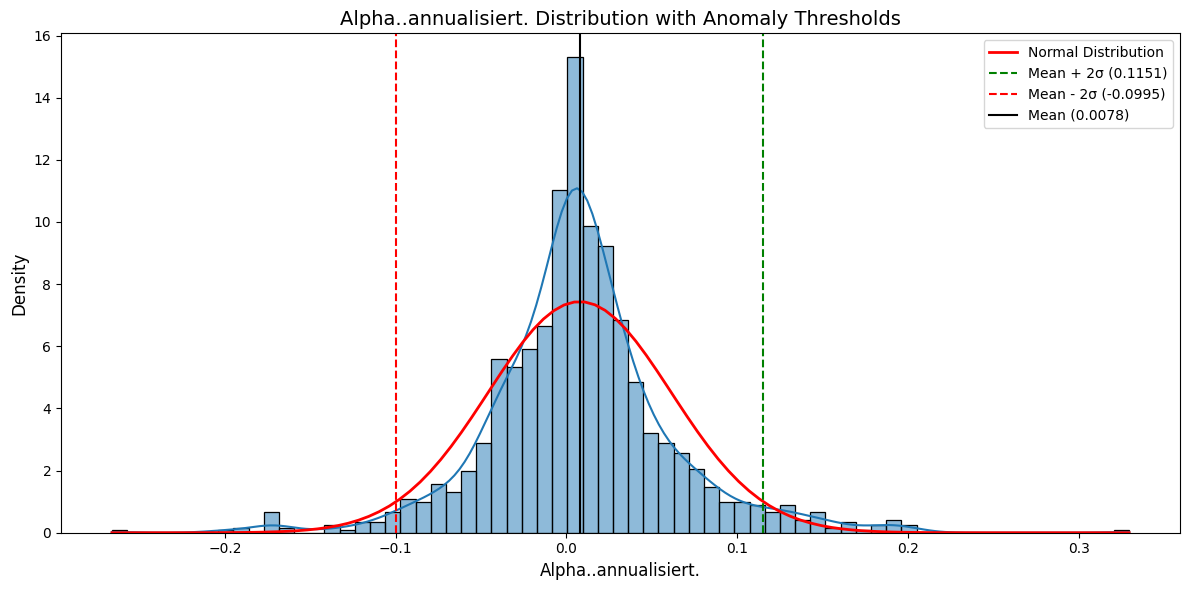

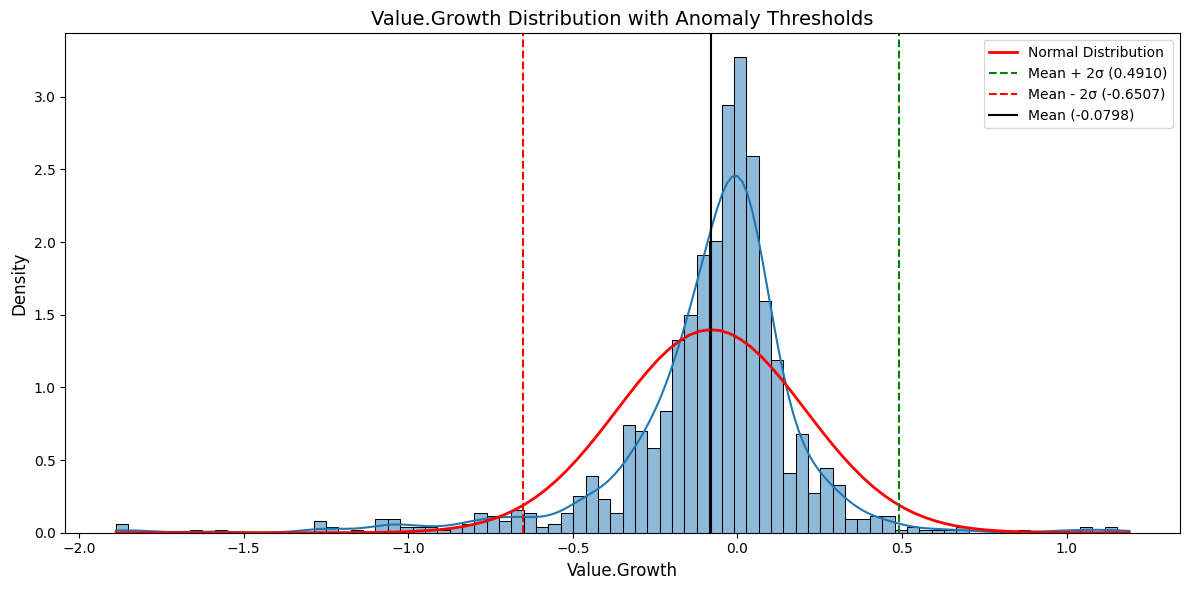

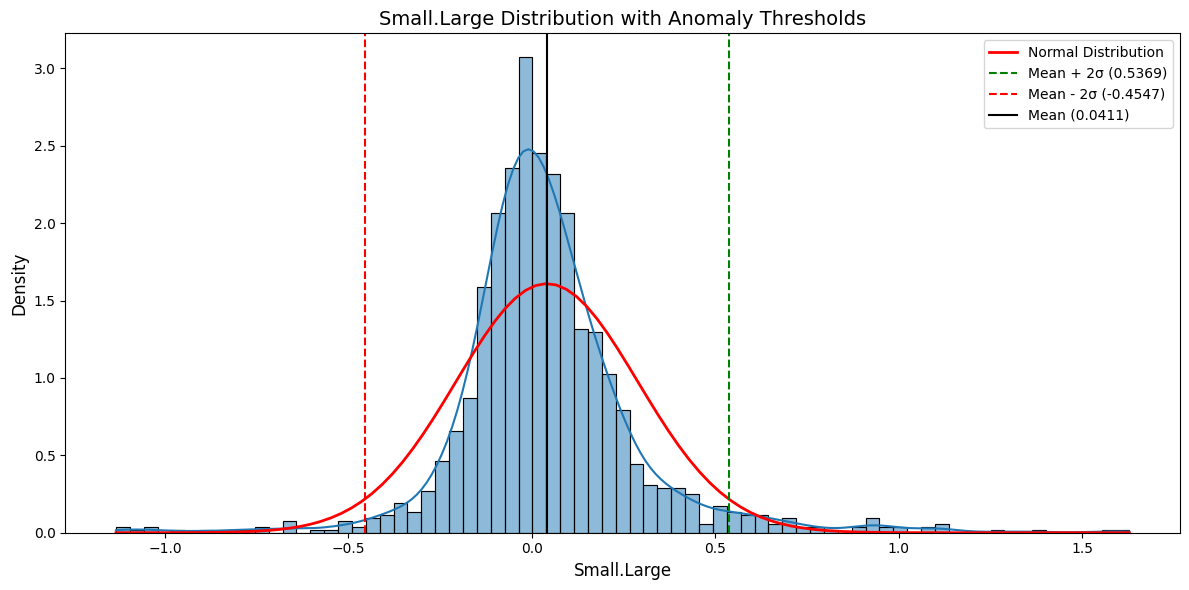

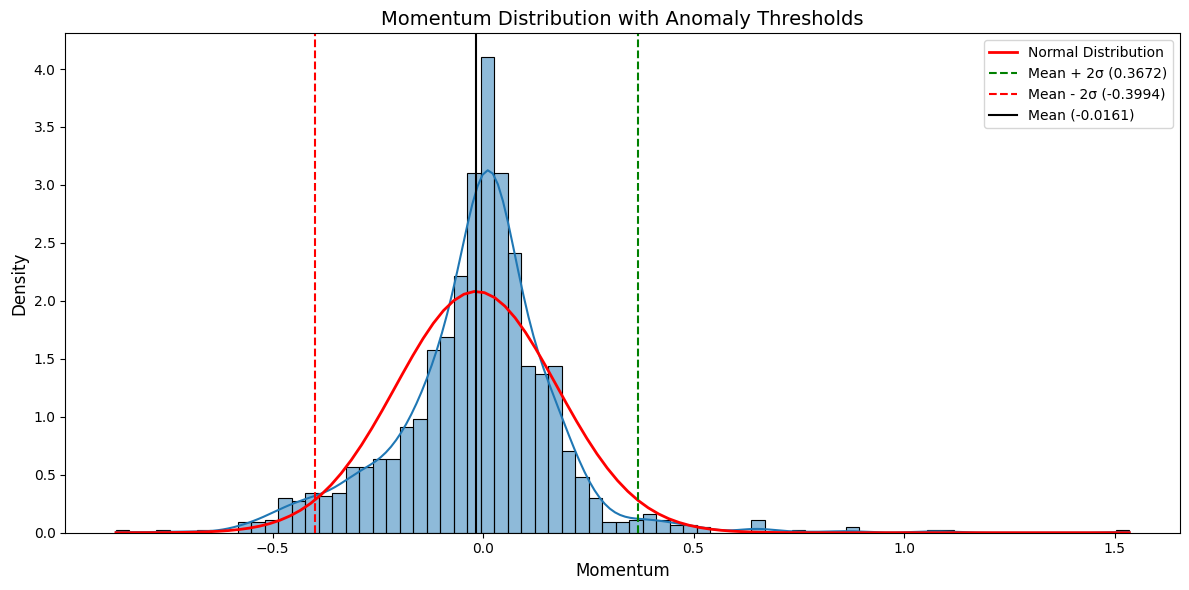

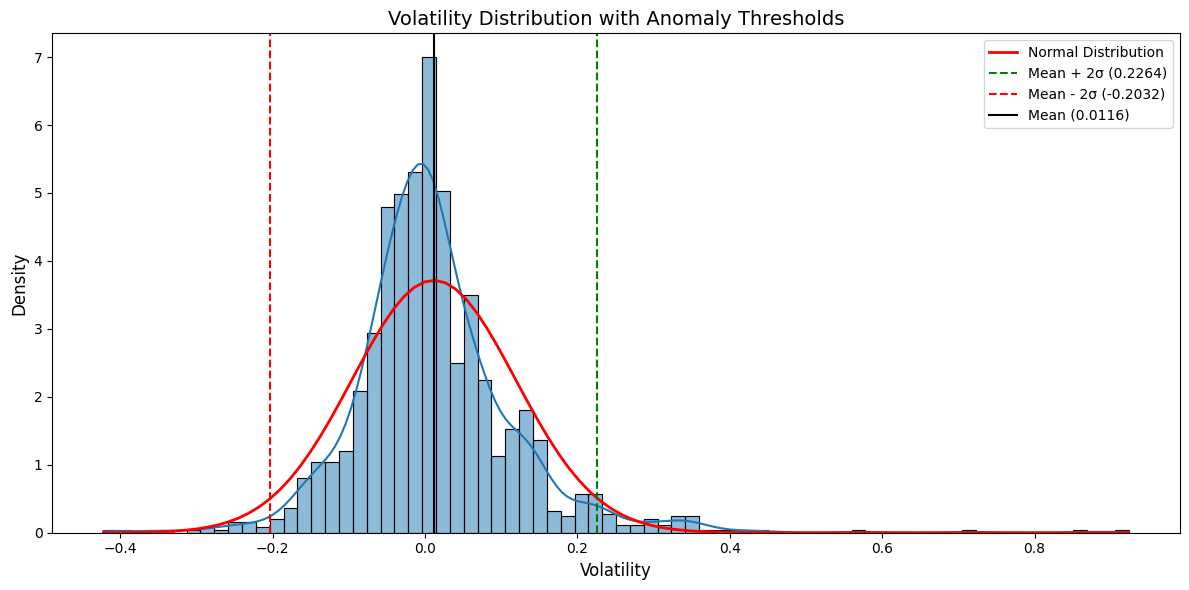

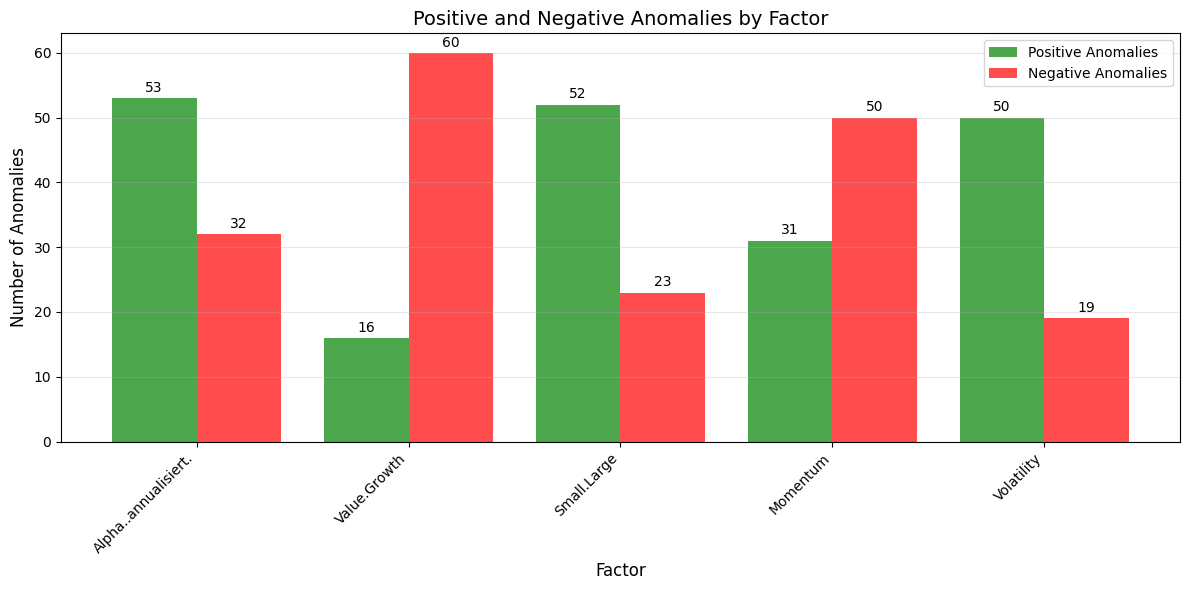

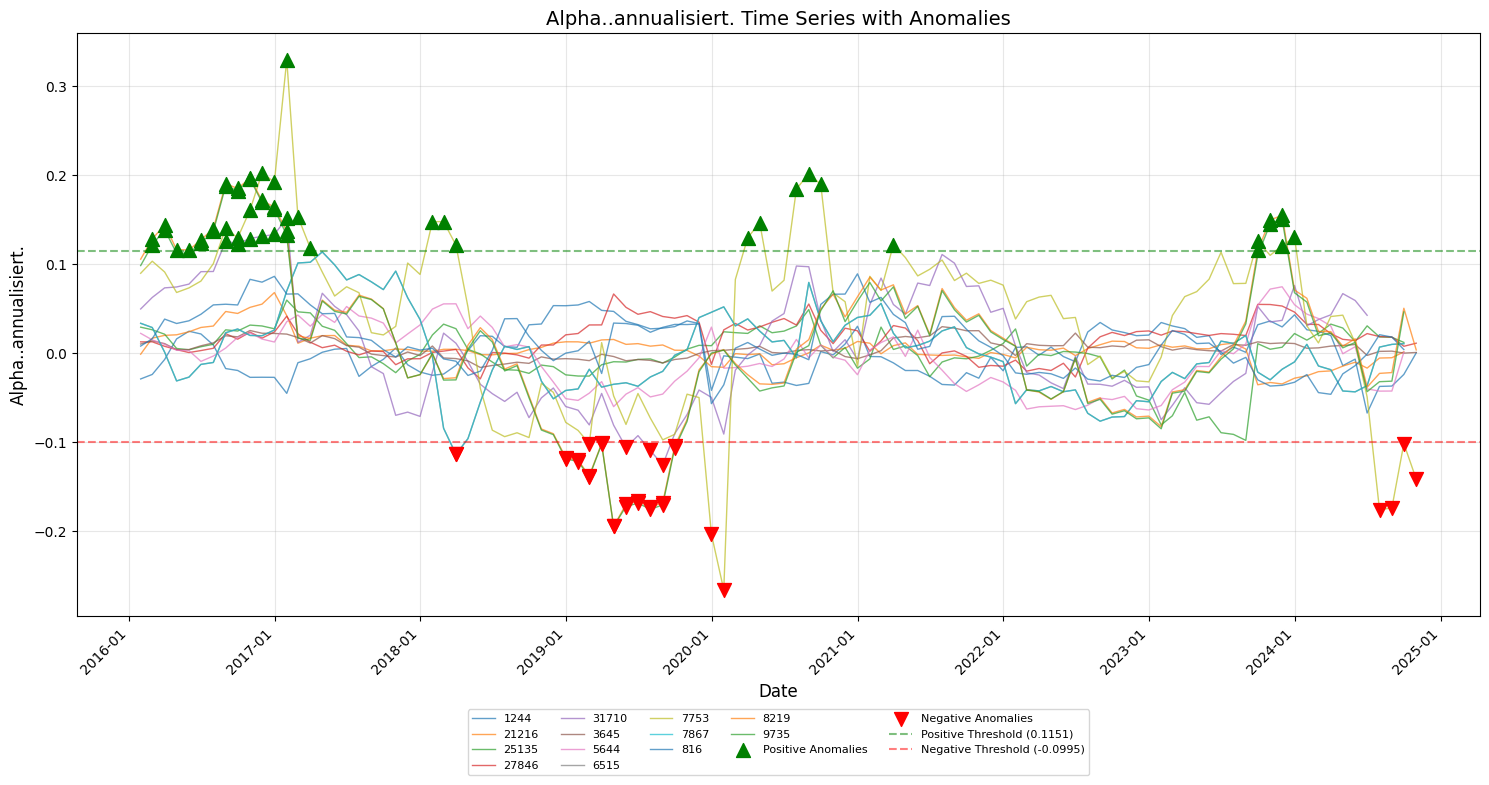

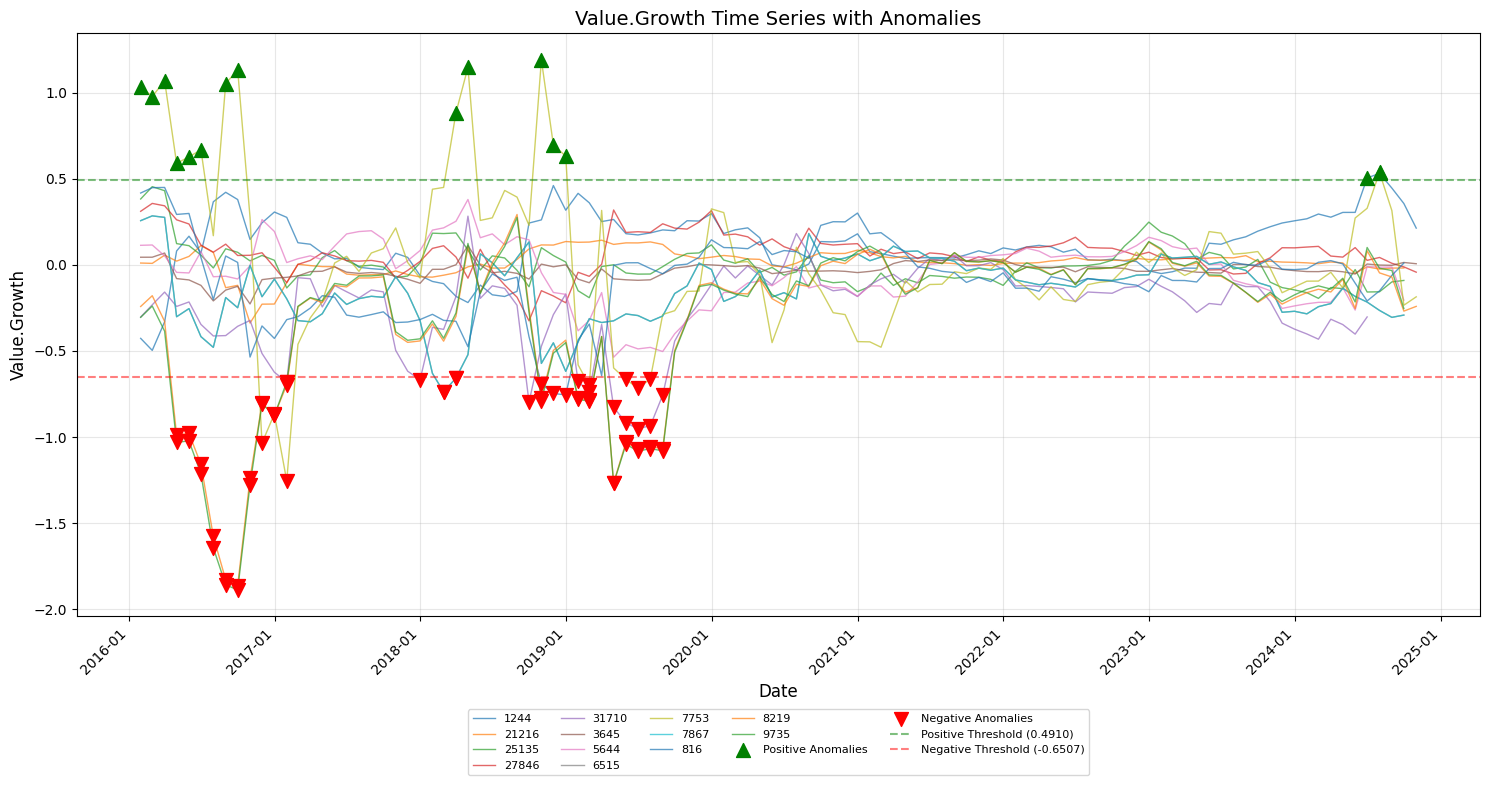

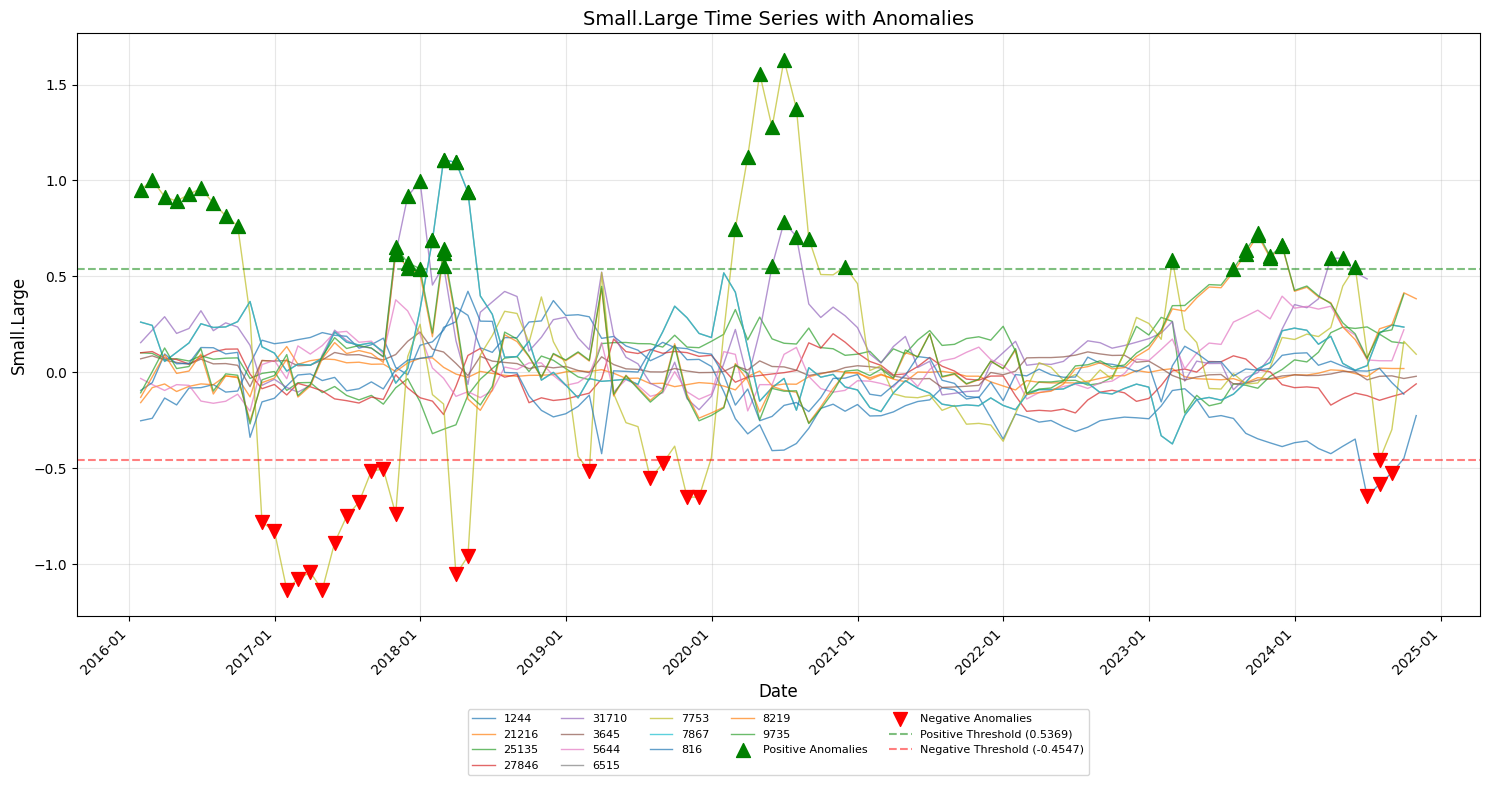

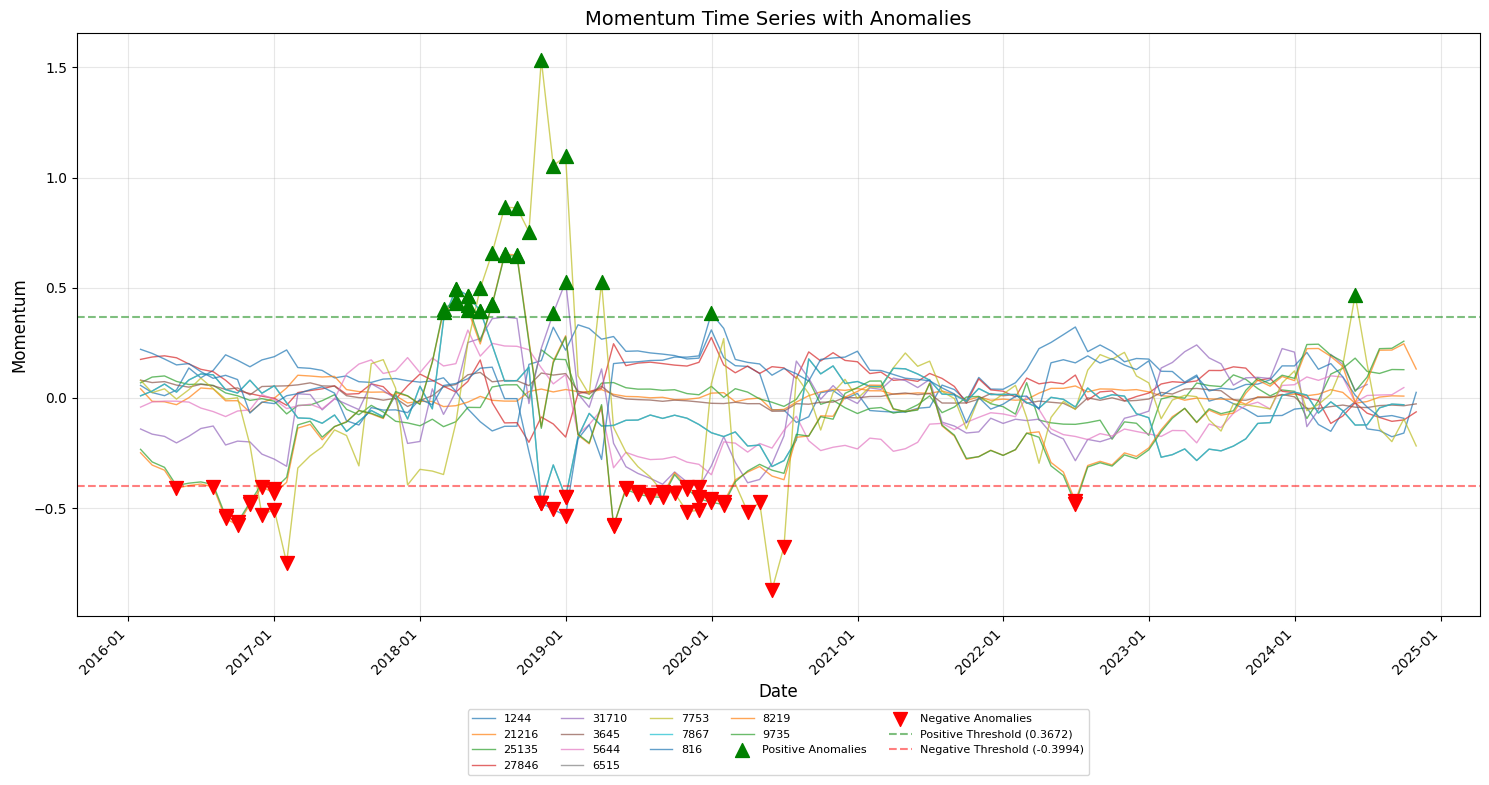

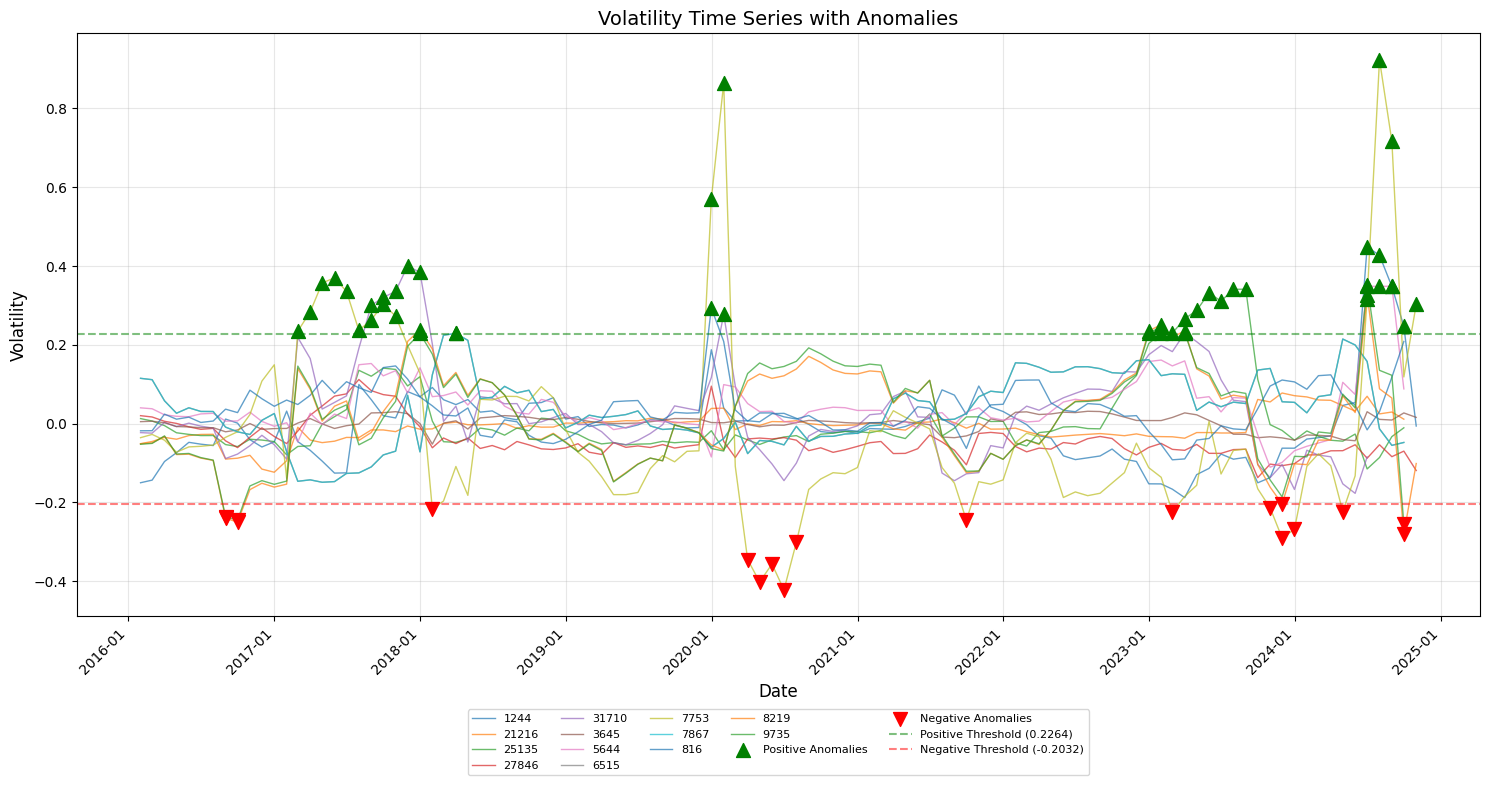

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
import seaborn as sns

class StatisticalFactorAnalyzer:
    """
    Analyzes factor data to detect and classify positive and negative anomalies
    using a statistical approach (mean ± std_threshold * standard deviation)
    """
    
    def __init__(self, factor_data_path='Factordata', output_dir=None):
        """
        Initialize the analyzer
        
        Parameters:
        -----------
        factor_data_path : str
            Path to directory containing factor data Excel files
        output_dir : str, optional
            Directory for saving output files. If None, uses 'factor_data_path/analysis_output'
        """
        self.factor_data_path = factor_data_path
        self.output_dir = output_dir or os.path.join(factor_data_path, 'analysis_output')
        os.makedirs(self.output_dir, exist_ok=True)
        
        self.factor_columns = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
    
    def load_factor_data(self):
        """
        Load factor data from Excel files
        
        Returns:
        --------
        dict
            Dictionary with mandate names as keys and factor DataFrames as values
        """
        excel_files = [f for f in os.listdir(self.factor_data_path) 
                      if f.endswith(('.xlsx', '.xls'))]
        
        all_factor_data = {}
        for file in excel_files:
            try:
                mandate_name = os.path.splitext(file)[0]
                file_path = os.path.join(self.factor_data_path, file)
                
                # Read factor data
                df = pd.read_excel(file_path)
                
                # Ensure there's a Date column
                if 'Date' not in df.columns:
                    print(f"No Date column found in {file}. Skipping.")
                    continue
                    
                df['Date'] = pd.to_datetime(df['Date'])
                df.set_index('Date', inplace=True)
                
                # Keep only factor columns that exist in this file
                available_factors = [col for col in self.factor_columns if col in df.columns]
                if not available_factors:
                    print(f"No factor columns found in {file}. Skipping.")
                    continue
                
                # Keep only required columns
                df = df[available_factors]
                
                all_factor_data[mandate_name] = df
                print(f"Loaded {mandate_name} with shape {df.shape}")
                
            except Exception as e:
                print(f"Error loading {file}: {e}")
                continue
        
        return all_factor_data
    
    def detect_anomalies(self, factor_data, std_threshold=2.0):
        """
        Detect and classify anomalies for all factors across all mandates
        using mean ± std_threshold * standard deviation
        
        Parameters:
        -----------
        factor_data : dict
            Dictionary with mandate names as keys and factor DataFrames as values
        std_threshold : float
            Number of standard deviations from the mean (default: 2.0)
            
        Returns:
        --------
        pd.DataFrame
            DataFrame with all detected anomalies
        dict
            Dictionary with anomaly counts by factor and direction
        """
        # Store all detected anomalies
        all_anomalies = []
        
        # Process each factor separately
        for factor in self.factor_columns:
            # Collect all values for this factor across all mandates
            all_values = []
            
            for mandate, df in factor_data.items():
                if factor in df.columns:
                    all_values.extend(df[factor].dropna().tolist())
            
            if not all_values:
                print(f"No data for factor {factor}. Skipping.")
                continue
                
            # Calculate statistics for this factor
            values_array = np.array(all_values)
            mean = np.mean(values_array)
            std = np.std(values_array)
            
            # Calculate thresholds using mean ± std_threshold * std
            high_threshold = mean + std_threshold * std
            low_threshold = mean - std_threshold * std
            
            print(f"\nThresholds for {factor}:")
            print(f"  Low (mean - {std_threshold} std): {low_threshold:.4f}")
            print(f"  High (mean + {std_threshold} std): {high_threshold:.4f}")
            print(f"  Mean: {mean:.4f}, Std: {std:.4f}")
            
            # Process each mandate
            for mandate, df in factor_data.items():
                if factor not in df.columns:
                    continue
                
                # Find anomalies for this factor in this mandate
                for date, value in df[factor].items():
                    if value >= high_threshold:
                        direction = 'positive'
                        all_anomalies.append({
                            'mandate': mandate,
                            'factor': factor,
                            'date': date,
                            'value': value,
                            'threshold': high_threshold,
                            'direction': direction,
                            'z_score': (value - mean) / std
                        })
                    elif value <= low_threshold:
                        direction = 'negative'
                        all_anomalies.append({
                            'mandate': mandate,
                            'factor': factor,
                            'date': date,
                            'value': value, 
                            'threshold': low_threshold,
                            'direction': direction,
                            'z_score': (value - mean) / std
                        })
        
        # Convert to DataFrame
        if not all_anomalies:
            print("No anomalies detected with the current threshold.")
            return pd.DataFrame(), {}
            
        anomalies_df = pd.DataFrame(all_anomalies)
        
        # Count anomalies by factor and direction
        anomaly_counts = {}
        for factor in self.factor_columns:
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if not factor_anomalies.empty:
                positive_count = len(factor_anomalies[factor_anomalies['direction'] == 'positive'])
                negative_count = len(factor_anomalies[factor_anomalies['direction'] == 'negative'])
                
                anomaly_counts[factor] = {
                    'positive': positive_count,
                    'negative': negative_count,
                    'total': positive_count + negative_count
                }
                
                print(f"{factor}: {positive_count} positive, {negative_count} negative anomalies")
        
        return anomalies_df, anomaly_counts
    
    def plot_anomaly_counts(self, anomaly_counts):
        """
        Create bar chart showing positive and negative anomalies by factor
        
        Parameters:
        -----------
        anomaly_counts : dict
            Dictionary with anomaly counts by factor and direction
        """
        if not anomaly_counts:
            print("No anomaly counts to plot.")
            return
        
        # Convert to DataFrame for plotting
        plot_data = []
        for factor, counts in anomaly_counts.items():
            plot_data.append({
                'factor': factor,
                'positive_anomalies': counts['positive'],
                'negative_anomalies': counts['negative']
            })
        
        df = pd.DataFrame(plot_data)
        
        # Create figure
        plt.figure(figsize=(12, 6))
        
        # Set width of bars
        bar_width = 0.4
        
        # Set positions of bars
        r1 = np.arange(len(df))
        r2 = [x + bar_width for x in r1]
        
        # Create bars
        positive_bars = plt.bar(r1, df['positive_anomalies'], width=bar_width, 
                             label='Positive Anomalies', color='green', alpha=0.7)
        negative_bars = plt.bar(r2, df['negative_anomalies'], width=bar_width, 
                             label='Negative Anomalies', color='red', alpha=0.7)
        
        # Add value labels on top of bars
        for bar in positive_bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height}', ha='center', va='bottom')
            
        for bar in negative_bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height}', ha='center', va='bottom')
        
        # Add labels and title
        plt.xlabel('Factor', fontsize=12)
        plt.ylabel('Number of Anomalies', fontsize=12)
        plt.title('Positive and Negative Anomalies by Factor', fontsize=14)
        
        # Set x-axis labels
        plt.xticks([r + bar_width/2 for r in range(len(df))], 
                  df['factor'], rotation=45, ha='right')
        
        # Add legend
        plt.legend()
        
        # Add grid lines
        plt.grid(axis='y', alpha=0.3)
        
        # Adjust layout
        plt.tight_layout()
        
        # Save figure
        output_file = os.path.join(self.output_dir, 
                               f'factor_anomaly_counts_{datetime.now():%Y%m%d_%H%M}.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Anomaly counts visualization saved to {output_file}")
    
    def plot_factor_time_series(self, factor_data, anomalies_df):
        """
        Create time series plots for each factor with anomalies highlighted
        
        Parameters:
        -----------
        factor_data : dict
            Dictionary with mandate names as keys and factor DataFrames as values
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if not factor_data or anomalies_df.empty:
            print("No data available for time series plots.")
            return
        
        # Process each factor
        for factor in self.factor_columns:
            # Check if we have anomalies for this factor
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if factor_anomalies.empty:
                print(f"No anomalies found for {factor}. Skipping time series plot.")
                continue
            
            # Create figure
            plt.figure(figsize=(15, 8))
            
            # Plot factor values for each mandate
            for mandate, df in factor_data.items():
                if factor in df.columns:
                    plt.plot(df.index, df[factor], '-', linewidth=1, label=mandate, alpha=0.7)
            
            # Highlight anomalies
            # Plot positive anomalies
            pos_anomalies = factor_anomalies[factor_anomalies['direction'] == 'positive']
            if not pos_anomalies.empty:
                plt.scatter(pos_anomalies['date'], pos_anomalies['value'], 
                          color='green', marker='^', s=100, label='Positive Anomalies', zorder=10)
            
            # Plot negative anomalies
            neg_anomalies = factor_anomalies[factor_anomalies['direction'] == 'negative']
            if not neg_anomalies.empty:
                plt.scatter(neg_anomalies['date'], neg_anomalies['value'], 
                          color='red', marker='v', s=100, label='Negative Anomalies', zorder=10)
            
            # Add threshold lines if available
            if 'threshold' in factor_anomalies.columns:
                pos_thresholds = pos_anomalies['threshold'].unique() if not pos_anomalies.empty else []
                neg_thresholds = neg_anomalies['threshold'].unique() if not neg_anomalies.empty else []
                
                for threshold in pos_thresholds[:1]:  # Just use the first one if multiple exist
                    plt.axhline(y=threshold, color='green', linestyle='--', alpha=0.5,
                              label=f'Positive Threshold ({threshold:.4f})')
                    
                for threshold in neg_thresholds[:1]:  # Just use the first one if multiple exist
                    plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.5,
                              label=f'Negative Threshold ({threshold:.4f})')
            
            # Add labels and title
            plt.xlabel('Date', fontsize=12)
            plt.ylabel(factor, fontsize=12)
            plt.title(f"{factor} Time Series with Anomalies", fontsize=14)
            
            # Format x-axis dates
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.gca().xaxis.set_major_locator(mdates.YearLocator())
            plt.xticks(rotation=45, ha='right')
            
            # Add grid
            plt.grid(alpha=0.3)
            
            # Add legend with smaller font to fit more items
            plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                     ncol=min(5, len(factor_data) + 3), fontsize=8)
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(self.output_dir, 
                                    f'{factor.replace(".", "_")}_time_series_{datetime.now():%Y%m%d_%H%M}.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            print(f"{factor} time series visualization saved to {output_file}")
    
    def plot_distribution(self, factor_data):
        """
        Create distribution plots for each factor showing the normal distribution
        and anomaly thresholds
        
        Parameters:
        -----------
        factor_data : dict
            Dictionary with mandate names as keys and factor DataFrames as values
        """
        for factor in self.factor_columns:
            # Collect all values for this factor
            all_values = []
            for mandate, df in factor_data.items():
                if factor in df.columns:
                    all_values.extend(df[factor].dropna().tolist())
            
            if not all_values:
                continue
                
            # Calculate statistics
            values_array = np.array(all_values)
            mean = np.mean(values_array)
            std = np.std(values_array)
            
            # Create figure
            plt.figure(figsize=(12, 6))
            
            # Plot histogram with kernel density
            sns.histplot(values_array, kde=True, stat="density")
            
            # Plot normal distribution curve
            x = np.linspace(min(values_array), max(values_array), 100)
            y = 1/(std * np.sqrt(2 * np.pi)) * np.exp(-(x - mean)**2 / (2 * std**2))
            plt.plot(x, y, 'r-', linewidth=2, label='Normal Distribution')
            
            # Add threshold lines for 2 standard deviations
            plt.axvline(x=mean + 2*std, color='green', linestyle='--', 
                      label=f'Mean + 2σ ({(mean + 2*std):.4f})')
            plt.axvline(x=mean - 2*std, color='red', linestyle='--', 
                      label=f'Mean - 2σ ({(mean - 2*std):.4f})')
            
            # Add mean line
            plt.axvline(x=mean, color='black', linestyle='-', 
                      label=f'Mean ({mean:.4f})')
            
            # Add labels and title
            plt.xlabel(factor, fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.title(f"{factor} Distribution with Anomaly Thresholds", fontsize=14)
            
            # Add legend
            plt.legend()
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(self.output_dir, 
                                     f'{factor.replace(".", "_")}_distribution_{datetime.now():%Y%m%d_%H%M}.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            print(f"{factor} distribution visualization saved to {output_file}")
    
    def run_analysis(self, std_threshold=2.0):
        """
        Run the complete analysis workflow
        
        Parameters:
        -----------
        std_threshold : float
            Number of standard deviations from mean for anomaly detection (default: 2.0)
        """
        print(f"Starting factor anomaly analysis with statistical method...")
        print(f"Using threshold of mean ± {std_threshold} standard deviations")
        
        # Load factor data
        print("\nLoading factor data...")
        factor_data = self.load_factor_data()
        
        if not factor_data:
            print("No factor data found. Analysis cannot proceed.")
            return
        
        # Create distribution plots
        print("\nCreating factor distribution visualizations...")
        self.plot_distribution(factor_data)
        
        # Detect anomalies
        print("\nDetecting anomalies...")
        anomalies_df, anomaly_counts = self.detect_anomalies(
            factor_data,
            std_threshold=std_threshold
        )
        
        if anomalies_df.empty:
            print("No anomalies detected. Try adjusting the standard deviation threshold.")
            return
        
        # Save anomalies data
        anomaly_csv = os.path.join(self.output_dir, 
                                 f'factor_anomalies_{datetime.now():%Y%m%d_%H%M}.csv')
        anomalies_df.to_csv(anomaly_csv, index=False)
        print(f"Anomalies data saved to {anomaly_csv}")
        
        # Create visualizations
        print("\nCreating anomaly count visualization...")
        self.plot_anomaly_counts(anomaly_counts)
        
        print("\nCreating factor time series visualizations...")
        self.plot_factor_time_series(factor_data, anomalies_df)
        
        print("\nAnalysis complete!")
        print(f"Results saved to {self.output_dir}")


def main():
    """
    Main execution function
    """
    try:
        # Create analyzer
        analyzer = StatisticalFactorAnalyzer()
        
        # Run analysis with 2 standard deviations threshold
        analyzer.run_analysis(std_threshold=2.0)
        
    except Exception as e:
        print(f"Error in analysis: {e}")
        import traceback
        print(traceback.format_exc())


if __name__ == "__main__":
    main()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 25.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
2025-03-04 06:21:47,850 - INFO - Starting integrated factor anomaly analysis...
2025-03-04 06:21:47,850 - INFO - Starting integrated factor anomaly analysis...
2025-03-04 06:21:47,850 - INFO - Starting integrated factor anomaly analysis...
2025-03-04 06:21:47,852 - INFO - Loading factor data...
2025-03-04 06:21:47,852 - INFO - Loading factor data...
2025-03-04 06:21:47,852 - INFO - Loading factor data...
2025-03-04 06:21:51,468 - INFO - Loading factor data from 1244.xlsx
2025-03-04 06:21:51,468 - INFO - Loading factor data from 1244.xlsx
2025-03-04 06:21:51,468 - INFO - Loading factor data from 1244.xlsx
2025-03-04 06:21:51,708 - INFO - Loaded 1244 with shape (106, 5)
2025-03-04 06:21:51,708 - INFO - Loaded 1244 with shape (106, 5)
2025-03-04 06:21:51,708 - INFO - Loaded 1244 with shape (106, 5)

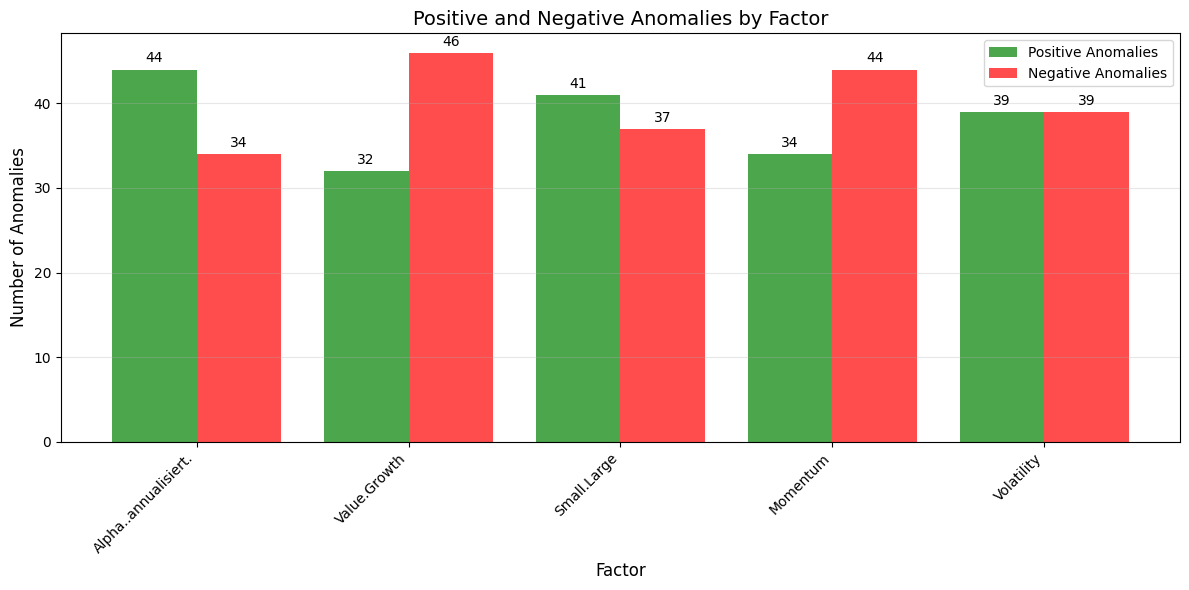

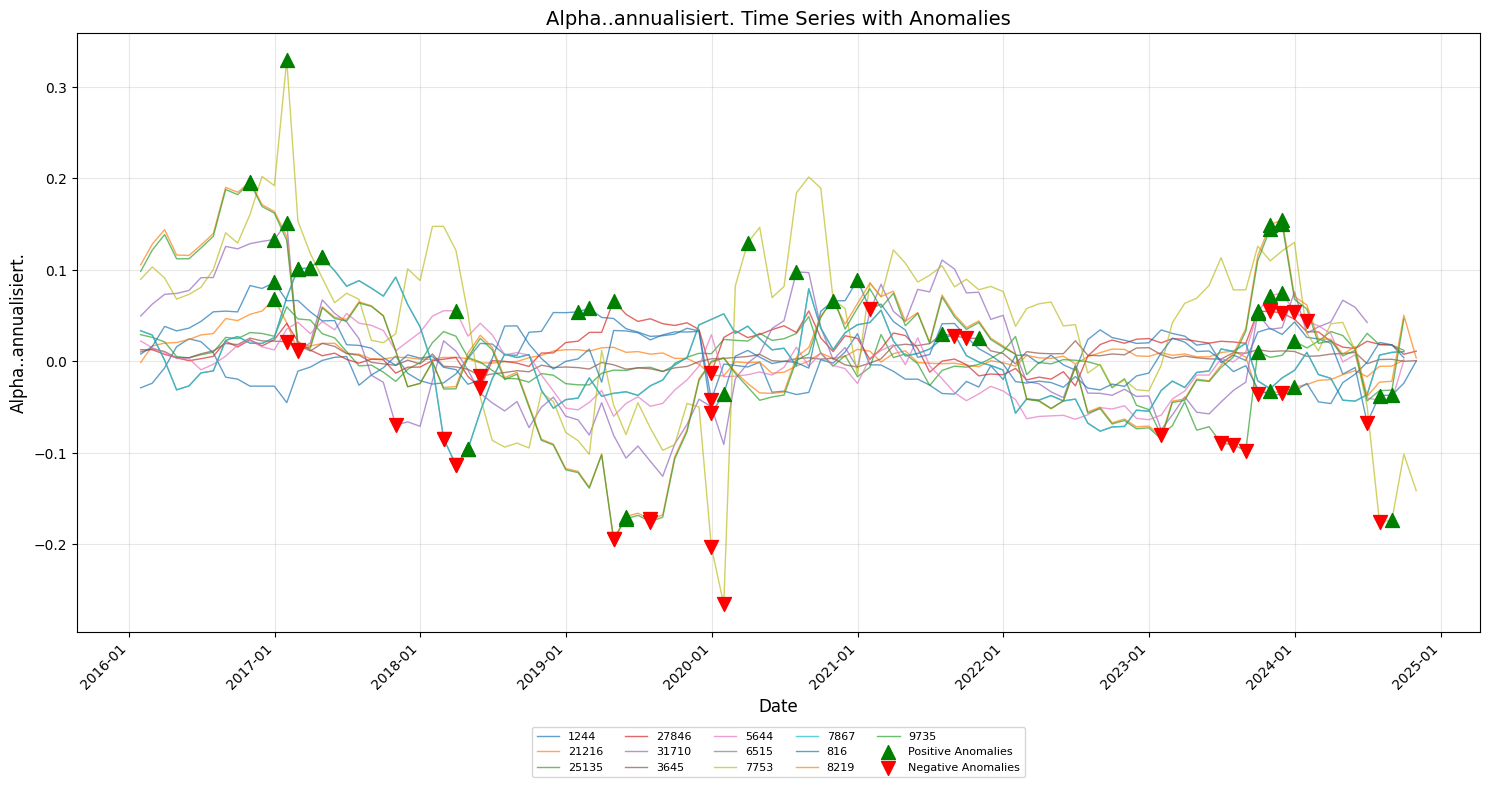

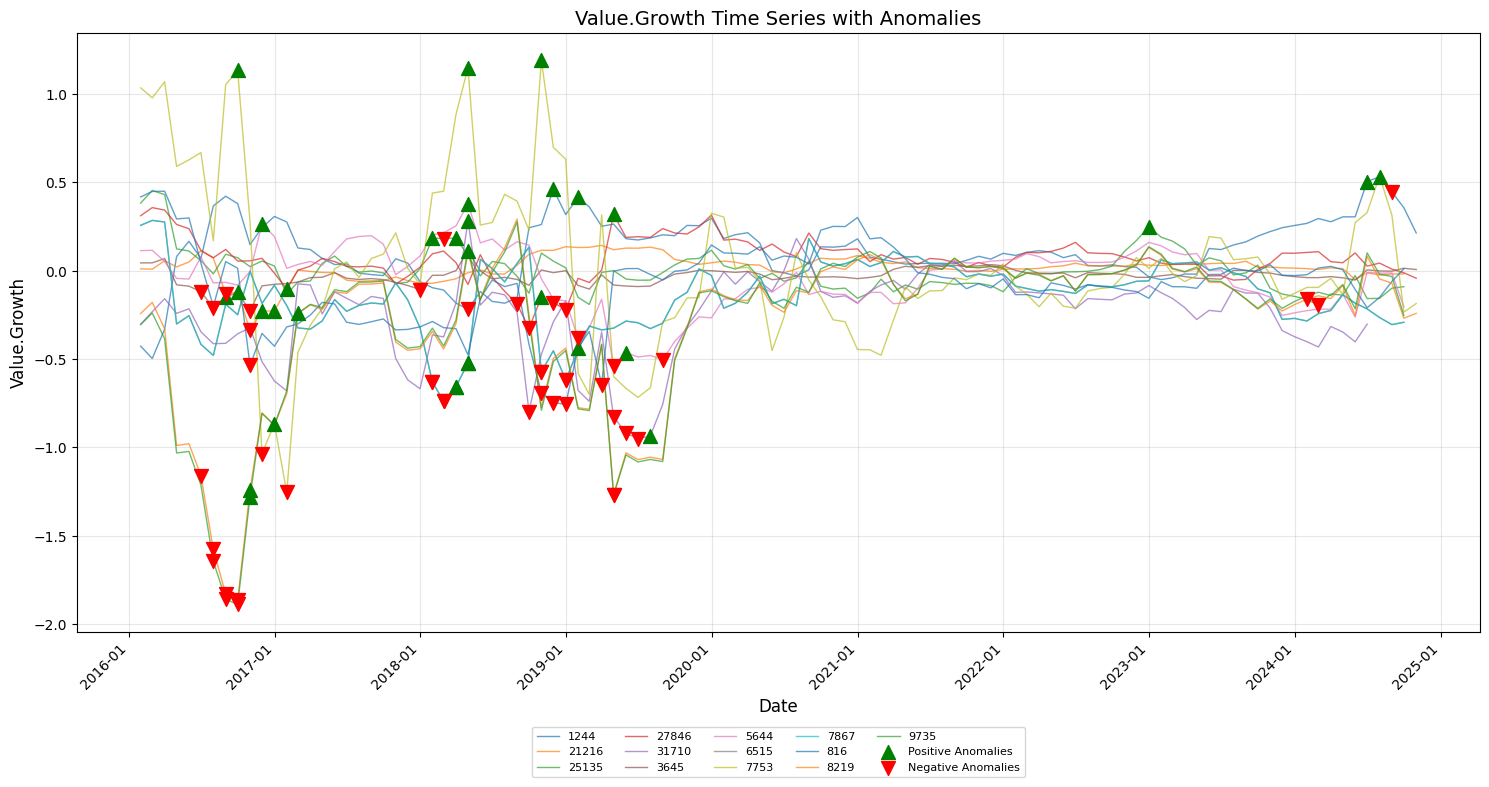

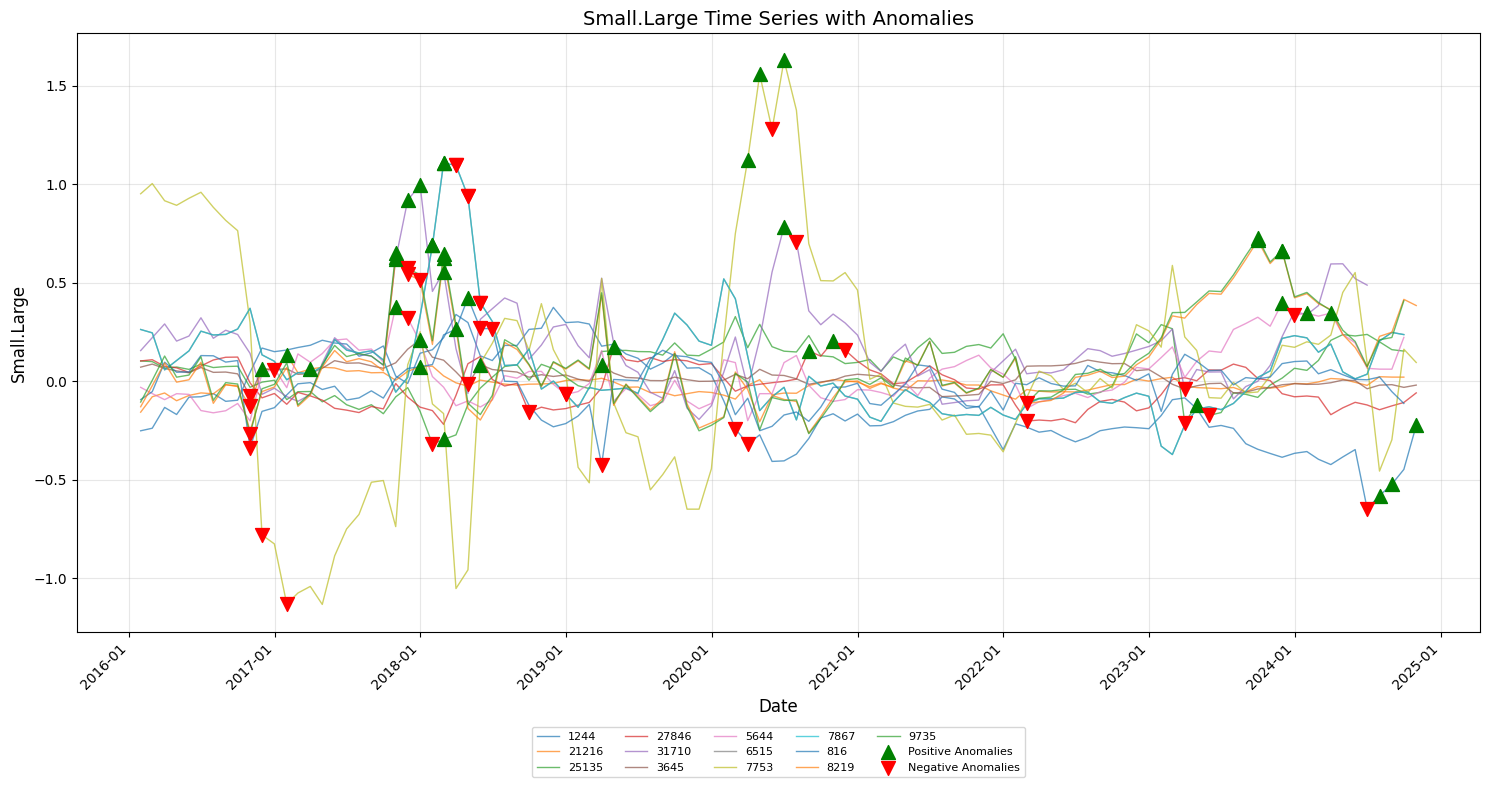

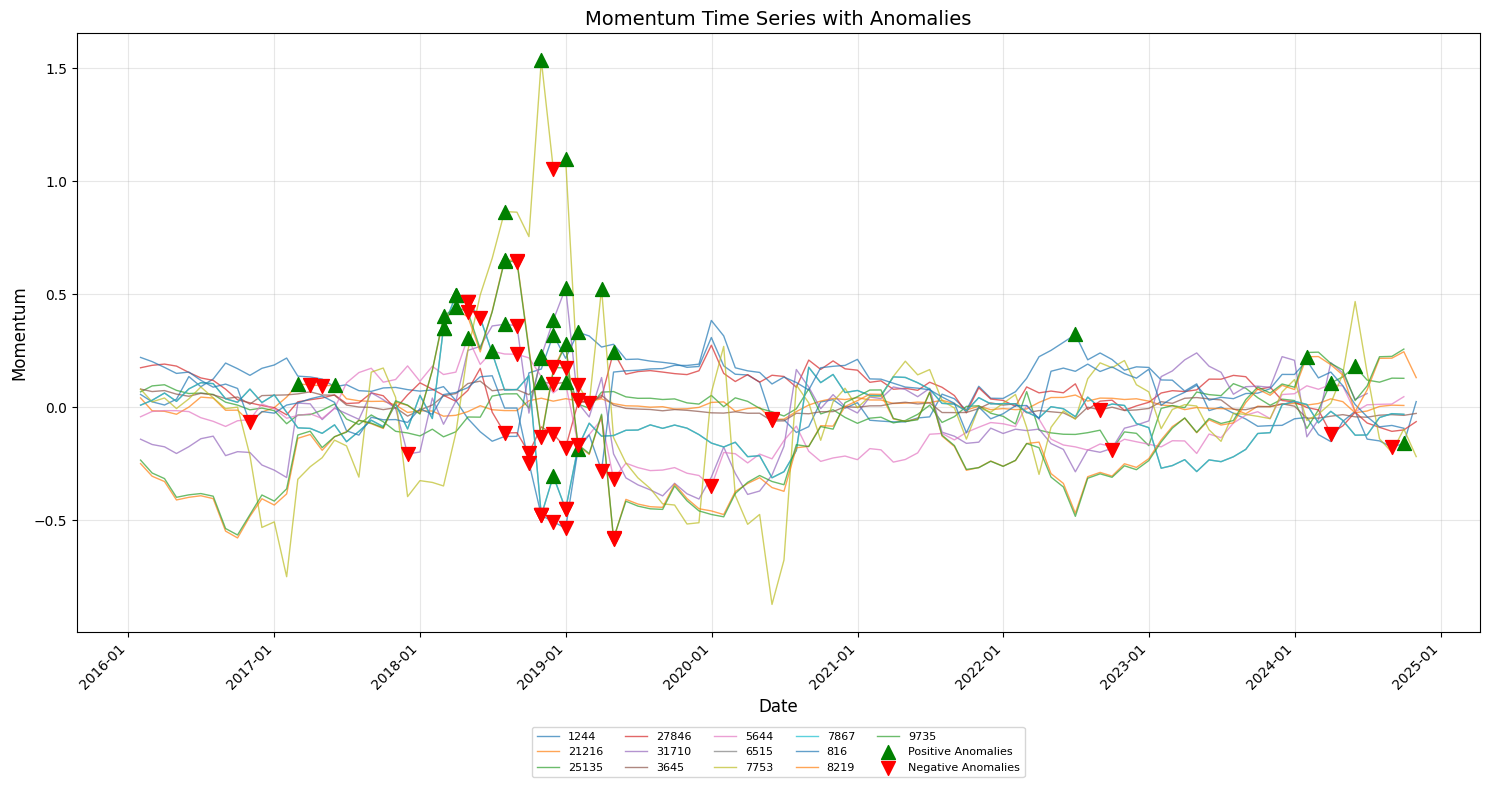

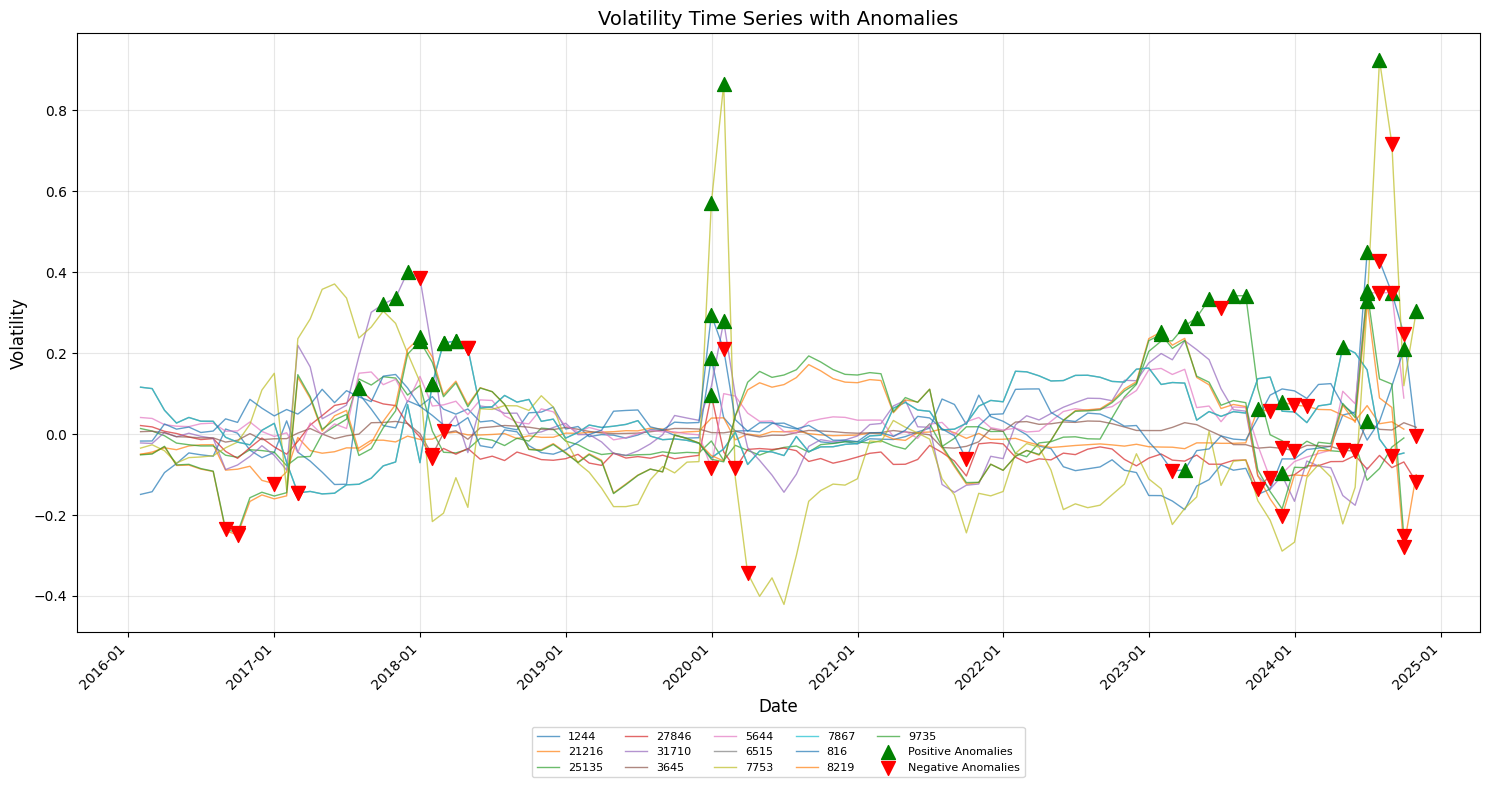

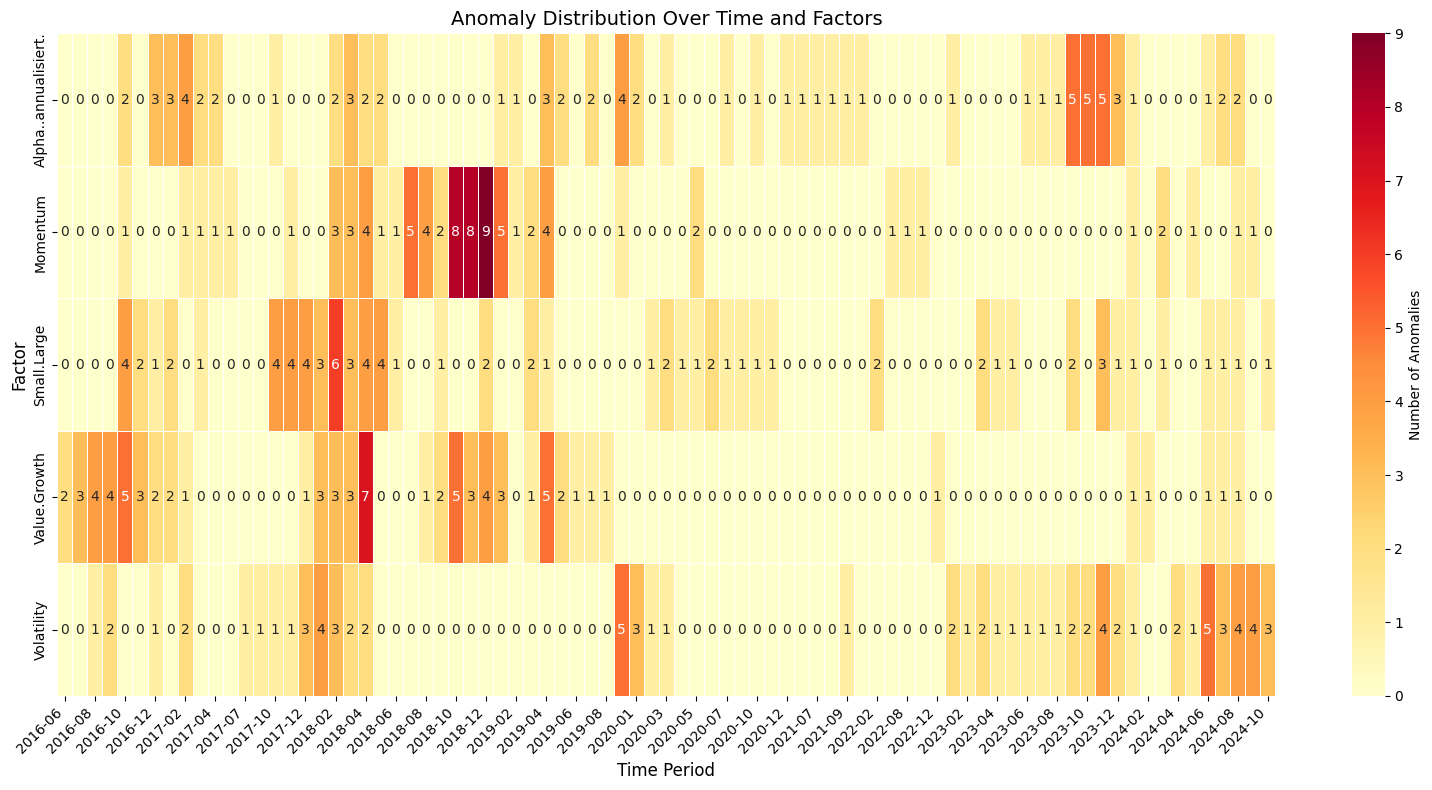

In [4]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
import seaborn as sns
import logging
import json
import warnings
warnings.filterwarnings('ignore')

# Machine learning imports
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Deep learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

class Config:
    """Configuration class for the integrated analyzer"""
    def __init__(self):
        # Paths
        self.FACTOR_DATA_PATH = 'Factordata'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_DATA_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        
        # Analysis parameters
        self.RANDOM_STATE = 42
        self.N_ESTIMATORS = 200
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        
        # LSTM parameters
        self.SEQUENCE_LENGTH = 5
        self.LSTM_UNITS = 64
        self.DROPOUT_RATE = 0.2
        self.EPOCHS = 50
        self.BATCH_SIZE = 32
        self.VALIDATION_SPLIT = 0.2
        self.ENSEMBLE_THRESHOLD = 0.5


def load_economic_data(logger, min_date=None, max_date=None):
    """
    Load economic data from CSV files in root directory
    
    Parameters:
    -----------
    logger : logging.Logger
        Logger object
    min_date : datetime, optional
        Minimum date for data filtering
    max_date : datetime, optional
        Maximum date for data filtering
        
    Returns:
    --------
    pd.DataFrame
        Economic data with date index
    """
    try:
        data_loaders = {
            'gdp': {
                'file': 'gdp_data.csv',
                'date_col': 'year_quarter',
                'value_cols': ['real_q', 'tsd_cleaned'],
                'rename': {'real_q': 'gdp'}
            },
            'unemployment': {
                'file': 'combined_unemployment_data.csv',
                'sep': ';',
                'date_col': 'Date',
                'value_cols': ['UnemploymentRate'],
                'numeric_cleaning': True
            },
            'ks': {
                'file': 'ks_q_hist.csv',
                'date_col': 'date',
                'value_cols': ['value']
            },
            'inflation': {
                'file': 'inflation.csv',
                'date_col': 'Date',
                'value_cols': ['chinf', 'usinf', 'deinf'],
                'numeric_cleaning': True
            },
            'gold': {
                'file': 'gold.csv',
                'date_col': 'Date',
                'value_cols': ['GoldCHF']
            },
            'eur_chf': {
                'file': 'EUR_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'EUR_CHF_rate'}
            },
            'usd_eur': {
                'file': 'USD_EUR_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_EUR_rate'}
            },
            'usd_chf': {
                'file': 'USD_CHF_monthly_rates.csv',
                'date_col': 'Date',
                'value_cols': ['Rate'],
                'rename': {'Rate': 'USD_CHF_rate'}
            },
            'sentiment': {
                'file': 'Sentiment_Per_Month.csv',
                'date_col': 'Time',
                'value_cols': ['Sentiment_12M', 'Sentiment_24M'],
                'date_parser': lambda x: pd.to_datetime(x, format='mixed')
            }
        }

        datasets = {}
        for key, config in data_loaders.items():
            try:
                file_path = config['file']
                if not os.path.exists(file_path):
                    logger.warning(f"File not found: {file_path}")
                    continue

                df = pd.read_csv(file_path, sep=config.get('sep', ','))
                
                # Date parsing with custom parser if specified
                if config.get('date_parser'):
                    df['date'] = config['date_parser'](df[config['date_col']])
                else:
                    df['date'] = pd.to_datetime(df[config['date_col']])
                
                if config.get('numeric_cleaning'):
                    for col in config['value_cols']:
                        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
                
                if config.get('rename'):
                    df = df.rename(columns=config['rename'])
                
                df = df[['date'] + list(config.get('rename', {}).values() or config['value_cols'])]
                
                if min_date is not None and max_date is not None:
                    df = df[(df['date'] >= min_date) & (df['date'] <= max_date)]
                
                df = df.sort_values('date')
                datasets[key] = df

            except Exception as e:
                logger.warning(f"Error loading {key} data: {e}")
                continue

        # Merge all datasets
        if 'gdp' not in datasets:
            logger.warning("GDP data not found, using empty DataFrame")
            # Create empty DataFrame with date index
            if min_date is not None and max_date is not None:
                date_range = pd.date_range(start=min_date, end=max_date, freq='MS')
                data = pd.DataFrame(index=date_range)
                data.index.name = 'date'
                return data
            else:
                raise ValueError("GDP data is required but could not be loaded")
        
        data = datasets['gdp'].copy()
        
        # Use outer merge and then forward fill missing values
        for key in ['unemployment', 'ks', 'inflation', 'gold', 
                   'eur_chf', 'usd_eur', 'usd_chf', 'sentiment']:
            if key in datasets:
                data = pd.merge_asof(data.sort_values('date'), 
                                   datasets[key].sort_values('date'),
                                   on='date',
                                   direction='nearest',
                                   tolerance=pd.Timedelta('30D'))
                
        # Forward fill missing values and then backward fill any remaining
        data = data.fillna(method='ffill').fillna(method='bfill')
        data.set_index('date', inplace=True)
        logger.info(f"Economic data loaded and filtered successfully with shape: {data.shape}")
        return data

    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        # Return empty DataFrame to allow continued execution
        if min_date is not None and max_date is not None:
            date_range = pd.date_range(start=min_date, end=max_date, freq='MS')
            data = pd.DataFrame(index=date_range)
            data.index.name = 'date'
            return data
        else:
            date_range = pd.date_range(start='2000-01-01', end='2023-01-01', freq='MS')
            data = pd.DataFrame(index=date_range)
            data.index.name = 'date'
            return data


class IntegratedFactorAnalyzer:
    """
    Integrated factor anomaly analyzer that combines economic data, LSTM models,
    and directional anomaly classification with enhanced visualizations
    """
    
    def __init__(self, config=None):
        """
        Initialize the integrated analyzer
        
        Parameters:
        -----------
        config : Config, optional
            Configuration object. If None, creates a default config.
        """
        self.config = config or Config()
        self.logger = self._setup_logger()
        self.lstm_models = {}

    def _setup_logger(self):
        """
        Set up logging for the analyzer
        
        Returns:
        --------
        logging.Logger
            Configured logger object
        """
        logger = logging.getLogger('integrated_factor_analysis')
        logger.setLevel(logging.INFO)
        
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        
        # File handler
        log_file = os.path.join(self.config.OUTPUT_DIR, 
                               f'factor_analysis_log_{datetime.now():%Y%m%d_%H%M}.log')
        fh = logging.FileHandler(log_file)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
        
        # Console handler
        ch = logging.StreamHandler()
        ch.setFormatter(formatter)
        logger.addHandler(ch)
        
        return logger

    def _build_lstm_model(self, n_features: int, factor: str):
        """
        Build LSTM model for anomaly detection
        
        Parameters:
        -----------
        n_features : int
            Number of input features
        factor : str
            Factor name for model identification
            
        Returns:
        --------
        None, stores model in self.lstm_models
        """
        model = Sequential([
            LSTM(self.config.LSTM_UNITS, 
                 input_shape=(self.config.SEQUENCE_LENGTH, n_features), 
                 return_sequences=True),
            Dropout(self.config.DROPOUT_RATE),
            LSTM(self.config.LSTM_UNITS // 2),
            Dropout(self.config.DROPOUT_RATE),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        self.lstm_models[factor] = model

    def _prepare_sequences(self, features: np.ndarray, target: np.ndarray):
        """
        Prepare sequences for LSTM training
        
        Parameters:
        -----------
        features : np.ndarray
            Input features
        target : np.ndarray
            Target values
            
        Returns:
        --------
        tuple
            X and y sequences for LSTM training
        """
        X, y = [], []
        for i in range(len(features) - self.config.SEQUENCE_LENGTH):
            X.append(features[i:(i + self.config.SEQUENCE_LENGTH)])
            y.append(target[i + self.config.SEQUENCE_LENGTH])
        return np.array(X), np.array(y)

    def load_factor_data(self):
        """
        Load factor data from Excel files in the factor data directory
        
        Returns:
        --------
        dict
            Dictionary with mandate names as keys and factor DataFrames as values
        """
        excel_files = [f for f in os.listdir(self.config.FACTOR_DATA_PATH) 
                      if f.endswith(('.xlsx', '.xls'))]
        
        all_factor_data = {}
        for file in excel_files:
            try:
                mandate_name = os.path.splitext(file)[0]
                file_path = os.path.join(self.config.FACTOR_DATA_PATH, file)
                
                # Read factor data
                self.logger.info(f"Loading factor data from {file}")
                df = pd.read_excel(file_path)
                
                # Ensure there's a Date column
                if 'Date' not in df.columns:
                    self.logger.warning(f"No Date column found in {file}. Skipping.")
                    continue
                    
                df['Date'] = pd.to_datetime(df['Date'])
                df.set_index('Date', inplace=True)
                
                # Keep only factor columns that exist in this file
                available_factors = [col for col in self.config.FACTOR_COLUMNS if col in df.columns]
                if not available_factors:
                    self.logger.warning(f"No factor columns found in {file}. Skipping.")
                    continue
                
                # Keep only required columns
                df = df[available_factors]
                
                all_factor_data[mandate_name] = df
                self.logger.info(f"Loaded {mandate_name} with shape {df.shape}")
                
            except Exception as e:
                self.logger.error(f"Error loading {file}: {e}")
                continue
        
        return all_factor_data

    def create_features(self, factor_data, economic_data=None):
        """
        Create enhanced features including economic data
        
        Parameters:
        -----------
        factor_data : dict
            Dictionary with mandate names as keys and factor DataFrames as values
        economic_data : pd.DataFrame, optional
            Economic data with date index
            
        Returns:
        --------
        dict
            Dictionary with enhanced DataFrames
        """
        enhanced_data = {}
        
        for mandate, df in factor_data.items():
            try:
                # Create a copy to avoid modifying the original
                enhanced_df = df.copy()
                
                # Add economic data if available
                if economic_data is not None:
                    # Resample economic data to match factor data frequency if needed
                    econ_resampled = economic_data.copy()
                    
                    # Merge with factor data
                    enhanced_df = enhanced_df.join(econ_resampled, how='left')
                    
                    # Handle any missing values from the join
                    economic_cols = economic_data.columns
                    for col in economic_cols:
                        if col in enhanced_df.columns and enhanced_df[col].isna().any():
                            enhanced_df[col] = enhanced_df[col].fillna(method='ffill').fillna(method='bfill')
                
                # Add time-based features
                enhanced_df['month'] = enhanced_df.index.month
                enhanced_df['quarter'] = enhanced_df.index.quarter
                enhanced_df['year'] = enhanced_df.index.year
                
                # Add rolling statistics for each factor
                for factor in self.config.FACTOR_COLUMNS:
                    if factor in enhanced_df.columns:
                        # Add rolling mean
                        enhanced_df[f'{factor}_rolling_mean_3'] = enhanced_df[factor].rolling(window=3, min_periods=1).mean()
                        enhanced_df[f'{factor}_rolling_mean_6'] = enhanced_df[factor].rolling(window=6, min_periods=1).mean()
                        
                        # Add rolling std
                        enhanced_df[f'{factor}_rolling_std_3'] = enhanced_df[factor].rolling(window=3, min_periods=1).std()
                        enhanced_df[f'{factor}_rolling_std_6'] = enhanced_df[factor].rolling(window=6, min_periods=1).std()
                        
                        # Add rate of change
                        enhanced_df[f'{factor}_pct_change'] = enhanced_df[factor].pct_change()
                
                # If we have economic data, add rolling stats for them too
                if economic_data is not None:
                    for col in economic_data.columns:
                        if col in enhanced_df.columns:
                            # Add rolling mean
                            enhanced_df[f'{col}_rolling_mean_3'] = enhanced_df[col].rolling(window=3, min_periods=1).mean()
                            enhanced_df[f'{col}_rolling_mean_6'] = enhanced_df[col].rolling(window=6, min_periods=1).mean()
                            
                            # Add rate of change
                            enhanced_df[f'{col}_pct_change'] = enhanced_df[col].pct_change()
                
                # Fill NaN values
                enhanced_df = enhanced_df.fillna(method='ffill').fillna(method='bfill')
                
                # Remove constant or near-constant features
                nunique = enhanced_df.nunique()
                cols_to_drop = nunique[nunique <= 1].index
                enhanced_df = enhanced_df.drop(columns=cols_to_drop)
                
                # Replace infinite values
                enhanced_df = enhanced_df.replace([np.inf, -np.inf], np.nan)
                enhanced_df = enhanced_df.fillna(method='ffill').fillna(method='bfill')
                
                # Store enhanced data
                enhanced_data[mandate] = enhanced_df
                
            except Exception as e:
                self.logger.error(f"Error creating features for {mandate}: {e}")
                # Keep original data as fallback
                enhanced_data[mandate] = factor_data[mandate].copy()
        
        return enhanced_data

    def detect_anomalies(self, enhanced_data):
        """
        Detect anomalies using both Isolation Forest and LSTM with direction classification
        
        Parameters:
        -----------
        enhanced_data : dict
            Dictionary with enhanced DataFrames
            
        Returns:
        --------
        pd.DataFrame
            DataFrame with all detected anomalies
        """
        all_anomalies = []
        
        for mandate, df in enhanced_data.items():
            self.logger.info(f"Analyzing anomalies for {mandate}...")
            
            # Process each factor
            for factor in self.config.FACTOR_COLUMNS:
                if factor not in df.columns:
                    continue
                
                try:
                    # Extract factor data
                    factor_values = df[factor].values
                    
                    # Create feature set by including relevant columns
                    feature_cols = [
                        col for col in df.columns 
                        if col != factor and not any(f in col for f in self.config.FACTOR_COLUMNS)
                        or col.startswith(f'{factor}_')
                    ]
                    
                    features = df[feature_cols].copy()
                    
                    # Scale features and factor values
                    feature_scaler = StandardScaler()
                    target_scaler = StandardScaler()
                    
                    features_scaled = feature_scaler.fit_transform(features)
                    factor_scaled = target_scaler.fit_transform(factor_values.reshape(-1, 1)).ravel()
                    
                    # Prepare LSTM sequences
                    X_seq, y_seq = self._prepare_sequences(features_scaled, factor_scaled)
                    
                    # Initialize and train LSTM if we have enough data
                    if len(X_seq) >= self.config.BATCH_SIZE:
                        self.logger.info(f"Training LSTM model for {factor} in {mandate}")
                        model_key = f"{mandate}_{factor}"
                        
                        if model_key not in self.lstm_models or \
                            self.lstm_models[model_key].input_shape[2] != features_scaled.shape[1]:
                            self._build_lstm_model(features_scaled.shape[1], model_key)
                        
                        # Train LSTM with early stopping
                        early_stopping = EarlyStopping(
                            monitor='val_loss',
                            patience=5,
                            restore_best_weights=True
                        )
                        
                        self.lstm_models[model_key].fit(
                            X_seq, y_seq,
                            epochs=self.config.EPOCHS,
                            batch_size=self.config.BATCH_SIZE,
                            validation_split=self.config.VALIDATION_SPLIT,
                            callbacks=[early_stopping],
                            verbose=0
                        )
                        
                        # Get LSTM predictions and scores
                        lstm_pred = self.lstm_models[model_key].predict(X_seq, verbose=0).ravel()
                        lstm_scores = np.abs(y_seq - lstm_pred)
                        lstm_scores = (lstm_scores - np.min(lstm_scores)) / (np.max(lstm_scores) - np.min(lstm_scores) + 1e-10)
                        
                        # Pad LSTM scores
                        padded_lstm_scores = np.zeros(len(df))
                        padded_lstm_scores[self.config.SEQUENCE_LENGTH:] = lstm_scores
                    else:
                        self.logger.warning(f"Insufficient data for LSTM training for {factor} in {mandate}")
                        padded_lstm_scores = np.zeros(len(df))
                    
                    # Use Isolation Forest
                    iso_forest = IsolationForest(
                        n_estimators=self.config.N_ESTIMATORS,
                        contamination='auto',
                        max_samples='auto',
                        random_state=self.config.RANDOM_STATE + hash(factor) % 1000,  # Unique seed
                        bootstrap=True,
                        n_jobs=-1
                    )
                    
                    # Fit model and get anomaly scores
                    if_predictions = iso_forest.fit_predict(features_scaled)
                    if_scores = iso_forest.score_samples(features_scaled)
                    
                    # Normalize scores between 0 and 1
                    if_scores = (if_scores - np.min(if_scores)) / (np.max(if_scores) - np.min(if_scores) + 1e-10)
                    if_scores = 1 - if_scores  # Invert so higher values = more anomalous
                    
                    # Combine IF and LSTM scores
                    if_weight = 0.4
                    lstm_weight = 0.6
                    
                    # Adjust weights based on factor characteristics
                    if 'Volatility' in factor:
                        if_weight = 0.3
                        lstm_weight = 0.7
                    elif 'Momentum' in factor:
                        if_weight = 0.5
                        lstm_weight = 0.5
                    
                    ensemble_scores = if_weight * if_scores + lstm_weight * padded_lstm_scores
                    
                    # Use 95th percentile for threshold
                    threshold = np.percentile(ensemble_scores, 95)
                    is_anomaly = ensemble_scores > threshold
                    
                    # For detected anomalies, determine direction (positive/negative)
                    for i in range(len(is_anomaly)):
                        if is_anomaly[i]:
                            # Determine direction by comparing with previous period
                            if i > 0:
                                direction = 'positive' if factor_values[i] > factor_values[i-1] else 'negative'
                            else:
                                # For first point, use the global average as reference
                                mean_value = np.mean(factor_values)
                                direction = 'positive' if factor_values[i] > mean_value else 'negative'
                            
                            # Record anomaly
                            all_anomalies.append({
                                'mandate': mandate,
                                'factor': factor,
                                'date': df.index[i],
                                'value': factor_values[i],
                                'if_score': if_scores[i],
                                'lstm_score': padded_lstm_scores[i],
                                'ensemble_score': ensemble_scores[i],
                                'threshold': threshold,
                                'direction': direction
                            })
                
                except Exception as e:
                    self.logger.error(f"Error detecting anomalies for {factor} in {mandate}: {e}")
                    continue
        
        # Convert to DataFrame
        if not all_anomalies:
            self.logger.warning("No anomalies detected.")
            return pd.DataFrame()
            
        anomalies_df = pd.DataFrame(all_anomalies)
        
        # Count anomalies by factor and direction
        for factor in self.config.FACTOR_COLUMNS:
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if not factor_anomalies.empty:
                positive_count = len(factor_anomalies[factor_anomalies['direction'] == 'positive'])
                negative_count = len(factor_anomalies[factor_anomalies['direction'] == 'negative'])
                
                self.logger.info(f"{factor}: {positive_count} positive, {negative_count} negative anomalies")
        
        return anomalies_df

    def plot_anomaly_counts(self, anomalies_df):
        """
        Create bar chart showing positive and negative anomalies by factor
        
        Parameters:
        -----------
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if anomalies_df.empty:
            self.logger.warning("No anomaly data to plot.")
            return
        
        # Count anomalies by factor and direction
        counts = {}
        for factor in self.config.FACTOR_COLUMNS:
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if not factor_anomalies.empty:
                positive_count = len(factor_anomalies[factor_anomalies['direction'] == 'positive'])
                negative_count = len(factor_anomalies[factor_anomalies['direction'] == 'negative'])
                
                counts[factor] = {
                    'positive': positive_count,
                    'negative': negative_count
                }
        
        # Convert to DataFrame for plotting
        plot_data = []
        for factor, count in counts.items():
            plot_data.append({
                'factor': factor,
                'positive_anomalies': count['positive'],
                'negative_anomalies': count['negative']
            })
        
        df = pd.DataFrame(plot_data)
        
        # Create figure
        plt.figure(figsize=(12, 6))
        
        # Set width of bars
        bar_width = 0.4
        
        # Set positions of bars
        r1 = np.arange(len(df))
        r2 = [x + bar_width for x in r1]
        
        # Create bars
        positive_bars = plt.bar(r1, df['positive_anomalies'], width=bar_width, 
                             label='Positive Anomalies', color='green', alpha=0.7)
        negative_bars = plt.bar(r2, df['negative_anomalies'], width=bar_width, 
                             label='Negative Anomalies', color='red', alpha=0.7)
        
        # Add value labels on top of bars
        for bar in positive_bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height}', ha='center', va='bottom')
            
        for bar in negative_bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height}', ha='center', va='bottom')
        
        # Add labels and title
        plt.xlabel('Factor', fontsize=12)
        plt.ylabel('Number of Anomalies', fontsize=12)
        plt.title('Positive and Negative Anomalies by Factor', fontsize=14)
        
        # Set x-axis labels
        plt.xticks([r + bar_width/2 for r in range(len(df))], 
                  df['factor'], rotation=45, ha='right')
        
        # Add legend
        plt.legend()
        
        # Add grid lines
        plt.grid(axis='y', alpha=0.3)
        
        # Adjust layout
        plt.tight_layout()
        
        # Save figure
        output_file = os.path.join(self.config.OUTPUT_DIR, 
                               f'factor_anomaly_counts_{datetime.now():%Y%m%d_%H%M}.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        self.logger.info(f"Anomaly counts visualization saved to {output_file}")
    
    def plot_factor_time_series(self, factor_data, anomalies_df):
        """
        Create time series plots for each factor with anomalies highlighted
        
        Parameters:
        -----------
        factor_data : dict
            Dictionary with mandate names as keys and factor DataFrames as values
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if not factor_data or anomalies_df.empty:
            self.logger.warning("No data available for time series plots.")
            return
        
        # Process each factor
        for factor in self.config.FACTOR_COLUMNS:
            # Check if we have anomalies for this factor
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if factor_anomalies.empty:
                self.logger.warning(f"No anomalies found for {factor}. Skipping time series plot.")
                continue
            
            # Create figure
            plt.figure(figsize=(15, 8))
            
            # Plot factor values for each mandate
            for mandate, df in factor_data.items():
                if factor in df.columns:
                    plt.plot(df.index, df[factor], '-', linewidth=1, label=mandate, alpha=0.7)
            
            # Highlight anomalies
            # Plot positive anomalies
            pos_anomalies = factor_anomalies[factor_anomalies['direction'] == 'positive']
            if not pos_anomalies.empty:
                plt.scatter(pos_anomalies['date'], pos_anomalies['value'], 
                          color='green', marker='^', s=100, label='Positive Anomalies', zorder=10)
            
            # Plot negative anomalies
            neg_anomalies = factor_anomalies[factor_anomalies['direction'] == 'negative']
            if not neg_anomalies.empty:
                plt.scatter(neg_anomalies['date'], neg_anomalies['value'], 
                          color='red', marker='v', s=100, label='Negative Anomalies', zorder=10)
            
            # Add labels and title
            plt.xlabel('Date', fontsize=12)
            plt.ylabel(factor, fontsize=12)
            plt.title(f"{factor} Time Series with Anomalies", fontsize=14)
            
            # Format x-axis dates
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.gca().xaxis.set_major_locator(mdates.YearLocator())
            plt.xticks(rotation=45, ha='right')
            
            # Add grid
            plt.grid(alpha=0.3)
            
            # Add legend with smaller font to fit more items
            plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                     ncol=min(5, len(factor_data) + 3), fontsize=8)
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(self.config.OUTPUT_DIR, 
                                    f'{factor.replace(".", "_")}_time_series_{datetime.now():%Y%m%d_%H%M}.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            self.logger.info(f"{factor} time series visualization saved to {output_file}")

    def plot_anomaly_heatmap(self, anomalies_df):
        """
        Create a heatmap showing the distribution of anomalies across time and factors
        
        Parameters:
        -----------
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if anomalies_df.empty:
            self.logger.warning("No anomaly data for heatmap.")
            return

        # Prepare data for heatmap
        # Group by year and month
        anomalies_df['year'] = anomalies_df['date'].dt.year
        anomalies_df['month'] = anomalies_df['date'].dt.month
        anomalies_df['yearmonth'] = anomalies_df['date'].dt.strftime('%Y-%m')
        
        # Count anomalies by factor and time period
        heatmap_data = anomalies_df.groupby(['factor', 'yearmonth']).size().unstack(fill_value=0)
        
        # Sort by time
        heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)
        
        # Create figure
        plt.figure(figsize=(16, 8))
        
        # Create heatmap
        sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=.5, annot=True, fmt='d', cbar_kws={'label': 'Number of Anomalies'})
        
        # Add labels and title
        plt.xlabel('Time Period', fontsize=12)
        plt.ylabel('Factor', fontsize=12)
        plt.title('Anomaly Distribution Over Time and Factors', fontsize=14)
        
        # Rotate x labels for better readability
        plt.xticks(rotation=45, ha='right')
        
        # Adjust layout
        plt.tight_layout()
        
        # Save figure
        output_file = os.path.join(self.config.OUTPUT_DIR, 
                                f'anomaly_heatmap_{datetime.now():%Y%m%d_%H%M}.png')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        self.logger.info(f"Anomaly heatmap saved to {output_file}")

    def plot_economic_correlation(self, enhanced_data, anomalies_df):
        """
        Plot correlation between economic indicators and factor anomalies
        
        Parameters:
        -----------
        enhanced_data : dict
            Dictionary with enhanced DataFrames
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if not enhanced_data or anomalies_df.empty:
            self.logger.warning("No data available for economic correlation analysis.")
            return
        
        # Get economic indicators (common across all mandates)
        mandate = list(enhanced_data.keys())[0]  # Take first mandate
        df = enhanced_data[mandate]
        
        # Identify economic columns (non-factor columns that aren't derived features)
        econ_cols = [col for col in df.columns 
                    if col not in self.config.FACTOR_COLUMNS 
                    and not any(fcol in col for fcol in self.config.FACTOR_COLUMNS)
                    and not col in ['month', 'quarter', 'year']]
        
        if not econ_cols:
            self.logger.warning("No economic indicators found for correlation analysis.")
            return
        
        # Create correlation matrix for each factor
        for factor in self.config.FACTOR_COLUMNS:
            # Get anomalies for this factor
            factor_anomalies = anomalies_df[anomalies_df['factor'] == factor]
            if factor_anomalies.empty:
                continue
            
            # Combine all mandate data for this factor
            factor_data = []
            for mandate, df in enhanced_data.items():
                if factor in df.columns:
                    mandate_df = df[[factor] + econ_cols].copy()
                    mandate_df['mandate'] = mandate
                    factor_data.append(mandate_df)
            
            if not factor_data:
                continue
                
            combined_df = pd.concat(factor_data)
            
            # Calculate correlation matrix
            correlation_matrix = combined_df[[factor] + econ_cols].corr()
            
            # Get correlations with the factor
            factor_correlations = correlation_matrix[factor].drop(factor)
            
            # Sort by absolute correlation value
            factor_correlations = factor_correlations.reindex(
                factor_correlations.abs().sort_values(ascending=False).index)
            
            # Take top 15 correlations
            top_correlations = factor_correlations.head(15)
            
            # Create figure
            plt.figure(figsize=(10, 8))
            
            # Create horizontal bar chart
            bars = plt.barh(top_correlations.index, top_correlations.values,
                          color=plt.cm.RdYlGn(top_correlations.values * 0.5 + 0.5))
            
            # Add value labels
            for i, v in enumerate(top_correlations.values):
                plt.text(v + 0.02 if v > 0 else v - 0.08, i, f'{v:.3f}', va='center')
            
            # Add labels and title
            plt.xlabel('Correlation Coefficient', fontsize=12)
            plt.title(f'Economic Indicators Correlation with {factor}', fontsize=14)
            
            # Add reference line at 0
            plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
            
            # Set x-axis limits
            plt.xlim(-1, 1)
            
            # Adjust layout
            plt.tight_layout()
            
            # Save figure
            output_file = os.path.join(self.config.OUTPUT_DIR, 
                                    f'{factor.replace(".", "_")}_econ_correlation_{datetime.now():%Y%m%d_%H%M}.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            self.logger.info(f"{factor} economic correlation visualization saved to {output_file}")
            
    def save_results_to_json(self, anomalies_df):
        """
        Save detected anomalies to JSON file
        
        Parameters:
        -----------
        anomalies_df : pd.DataFrame
            DataFrame with detected anomalies
        """
        if anomalies_df.empty:
            self.logger.warning("No anomalies to save.")
            return
        
        try:
            # Convert to serializable format
            anomalies_json = anomalies_df.copy()
            anomalies_json['date'] = anomalies_json['date'].dt.strftime('%Y-%m-%d')
            
            # Save as JSON
            output_file = os.path.join(self.config.OUTPUT_DIR, 
                                     f'anomalies_{datetime.now():%Y%m%d_%H%M}.json')
            
            with open(output_file, 'w') as f:
                json.dump(anomalies_json.to_dict(orient='records'), f, indent=2)
                
            self.logger.info(f"Anomalies saved to {output_file}")
            
        except Exception as e:
            self.logger.error(f"Error saving anomalies to JSON: {e}")
            
    def run_analysis(self):
        """
        Run the complete integrated analysis workflow
        """
        self.logger.info("Starting integrated factor anomaly analysis...")
        
        # Load factor data
        self.logger.info("Loading factor data...")
        factor_data = self.load_factor_data()
        
        if not factor_data:
            self.logger.error("No factor data found. Analysis cannot proceed.")
            return
        
        # Get date range from factor data
        all_dates = []
        for mandate, df in factor_data.items():
            all_dates.extend(df.index.tolist())
        
        min_date = min(all_dates)
        max_date = max(all_dates)
        
        # Load economic data
        self.logger.info(f"Loading economic data from {min_date} to {max_date}...")
        economic_data = load_economic_data(self.logger, min_date, max_date)
        
        # Create enhanced features with economic data
        self.logger.info("Creating enhanced features with economic data...")
        enhanced_data = self.create_features(factor_data, economic_data)
        
        # Detect anomalies using both LSTM and Isolation Forest
        self.logger.info("Detecting anomalies using enhanced ensemble approach...")
        anomalies_df = self.detect_anomalies(enhanced_data)
        
        if anomalies_df.empty:
            self.logger.warning("No anomalies detected. Analysis cannot proceed further.")
            return
        
        # Save results to CSV and JSON
        anomaly_csv = os.path.join(self.config.OUTPUT_DIR, 
                                 f'factor_anomalies_{datetime.now():%Y%m%d_%H%M}.csv')
        anomalies_df.to_csv(anomaly_csv, index=False)
        self.logger.info(f"Anomalies data saved to {anomaly_csv}")
        
        self.save_results_to_json(anomalies_df)
        
        # Create visualizations
        self.logger.info("Creating visualizations...")
        
        # Anomaly counts
        self.logger.info("Creating anomaly count visualization...")
        self.plot_anomaly_counts(anomalies_df)
        
        # Factor time series
        self.logger.info("Creating factor time series visualizations...")
        self.plot_factor_time_series(factor_data, anomalies_df)
        
        # Anomaly heatmap
        self.logger.info("Creating anomaly heatmap...")
        self.plot_anomaly_heatmap(anomalies_df)
        
        # Economic correlation
        self.logger.info("Creating economic correlation visualizations...")
        self.plot_economic_correlation(enhanced_data, anomalies_df)
        
        self.logger.info("Analysis complete!")
        self.logger.info(f"Results saved to {self.config.OUTPUT_DIR}")


def main():
    """
    Main execution function
    """
    try:
        # Create configuration
        config = Config()
        
        # Create analyzer
        analyzer = IntegratedFactorAnalyzer(config)
        
        # Run analysis
        analyzer.run_analysis()
        
    except Exception as e:
        print(f"Error in analysis: {e}")
        import traceback
        print(traceback.format_exc())


if __name__ == "__main__":
    main()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b0d79e99-778c-4964-b163-e34d369ad413' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>